# NOTEBOOK EDA

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import chi2_contingency
from itertools import combinations
from scipy.stats import f_oneway

import os
import re

from IPython.display import display, Markdown

import missingno as msno
import sys

from rapidfuzz import process, fuzz

from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\JAIME\Documents\Github\TFM-Sesgos-en-el-sistema-judicial-de-EEUU-\00_Data\00_Processed\df_eda.csv")

In [3]:
def convert_to_datetime(df):
    date_regex = r'^(?:(?:\d{4}[-/]\d{1,2}[-/]\d{1,2})|(?:\d{1,2}[-/]\d{1,2}[-/]\d{2,4}))(?:[\sT]+(?:[01]?\d|2[0-3]):[0-5]\d(?::[0-5]\d)?)?$'

    for col in df.columns:
        if df[col].dtype.name == 'object':
            mask = df[col].dropna().str.match(date_regex)
            if mask.all():
                df[col] = pd.to_datetime(df[col], errors='coerce', infer_datetime_format=True)

    return df

In [4]:
def convert_categorical(df):
    age_order = ['less than 25', '25-45', '46-65', 'greater than 65']
    score_order = ['low', 'medium', 'high']
    charge_degree_order = ["misdemeanor", "felony"]


    df["age_cat"] = pd.Categorical(df["age_cat"], categories= age_order, ordered=True)
    df["score_text"] = pd.Categorical(df["score_text"], categories= score_order, ordered=True)
    df["c_charge_degree"] = pd.Categorical(df["c_charge_degree"], categories= charge_degree_order, ordered=True)
    df['days_in_jail_cat'] = pd.qcut(df['days_in_jail'], q=5, labels=['Muy bajo', 'Bajo', 'Medio', 'Alto', 'Muy alto'])

    return df

In [5]:
df.columns

Index(['sex', 'race', 'age', 'age_cat', 'decile_score', 'v_decile_score',
       'is_recid', 'is_violent_recid', 'score_text', 'screening_date',
       'two_year_recid', 'priors_count', 'c_charge_degree', 'start', 'end',
       'event', 'c_jail_in', 'c_jail_out', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'person_id', 'agency_text', 'maritalstatus',
       'language', 'rawscore', 'days_in_jail', 'juv_priors_count'],
      dtype='object')

In [6]:
df["score_text"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [7]:
df = convert_to_datetime(df)

In [8]:
df = convert_categorical(df)

## Guión


### -Sacar gráficos
    - Estadísticos descriptivos de las variables
    - .corr de scores y demográficas
    - is_recid y is_v_recid con demográficas
    - cantidad de falsos positivos y falsos negativos + porcentaje de acierto del score
    - Tablas de contigencias de variables demográficas sobre is_recid y v_is_recid y score intervalos

In [ ]:
# En bar plot (plotly), animation_frame para la barra interactuable
def eda(df):
    lista_variables_numericas = df.select_dtypes(include = "number").columns.tolist()
    lista_variables_numericas.remove("person_id")
    lista_variables_categoricas = df.select_dtypes(include = ["object", "category"]).columns.tolist()
    lista_variables_temporales = df.select_dtypes(include = "datetime").columns.tolist()
    lista_booleanos = df[["is_recid", "is_violent_recid"]].columns.tolist()
    lista_chi2 = lista_variables_categoricas + lista_booleanos
    
    display(Markdown("# Análisis univariable"))

    for col in lista_variables_categoricas:
    # Sacamos valores únicos y sus conteos
        counts = df[col].value_counts(dropna=False)
        
        if df[col].nunique() <= 3:
            # Preparamos labels con nombre + conteo
            labels = [f'{valor}\n{count}' for valor, count in zip(counts.index, counts.values)]
            
            # Dibujamos el pie chart
            plt.figure()
            plt.pie(
                counts.values,
                labels=labels,
                autopct='%1.1f%%'
            )
            
            plt.title(f'Distribución de {col}')
            plt.show()

        else:
            total = counts.sum()

            df_count = counts.reset_index()
            df_count.columns = [col, "frecuencia"]
            df_count["pct"] = df_count["frecuencia"] / total

            fig = px.bar(
                df_count,
                x=col,
                y='frecuencia',
                text= df_count.apply(
                lambda r: f"{r['pct']:.1%}",
                axis=1
            ),
            )

            fig.update_layout(
            title=f'Número de personas por {col}',
            yaxis_title='Número de personas'
            )

            fig.show()


    # df["ethnic_code_text"].value_counts().plot(kind="bar")
    # plt.title('Distribucion de personas por raza')
    # plt.show()

    
    print(f"Media:\n{df[lista_variables_numericas].mean()}")
    print("\n")
    print(f"Mediana:\n{df[lista_variables_numericas].median()}")
    print("\n")
    print(f"Mínimo:\n{df[lista_variables_numericas].min()}")
    print("\n")
    print(f"Máximo:\n{df[lista_variables_numericas].max()}")
    print("\n")
    print(f"Varianza:\n{df[lista_variables_numericas].var()}")
    print("\n")
    print(f"Desviación típica:\n{df[lista_variables_numericas].std()}")
    print("\n")
    print(f"Moda:\n{df[lista_variables_numericas].mode()}")

    for col in lista_variables_numericas:
        df[[col]].boxplot(figsize=(8,5))
        plt.title(f"Distribución general de {col}")
        plt.show()
        print("\n")

    display(Markdown("# Análisis bivariable"))
    print("\n")

    for col_num in lista_variables_numericas:
        for col_cat in lista_variables_categoricas:
            if col_cat != "sex":
                sns.boxplot(
                    data= df,
                    x=col_cat,
                    y= col_num,
                    hue="sex"
                )
                plt.title(f"Distribución de {col_num} por género y {col_cat}")
                plt.show()
                print("\n")

    # for col_num1 in lista_variables_numericas:
    #     for col_num2 in lista_variables_numericas:
    #         if col_num1 != col_num2:
    #             sns.relplot(
    #                 data= df,
    #                 x=col_num2,
    #                 y= col_num1,
                    
    #             )
    #             plt.title(f"Distribución de {col_num2} por {col_num1}")
    #             plt.show()
    #             print("\n")



    corr_matrix = df[lista_variables_numericas].corr(method= "spearman")

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        center=0
    )

    plt.title("Matriz de correlación")
    plt.show()

    

 
    # for var in lista_variables_numericas:
    #     sns.lineplot(
    #         data=df,
    #         x="Año",
    #         y=var,
    #         hue="sex",
    #         marker="o"
    #     )
    #     plt.title(f"Evolución temporal de {var}")
    #     plt.xticks(df["Año"].unique())
    #     plt.show()
    #     print("\n")

    for col1, col2 in combinations(lista_chi2, 2):
        tabla = pd.crosstab(df[col1], df[col2], margins= True)
        chi2, p, dof, expected = chi2_contingency(tabla)
        if(p <= 0.05):
            print(f"\nCrosstab entre {col1} y {col2}")
            display(tabla)


In [10]:
# df = df.set_index("person_id")

# Análisis univariable

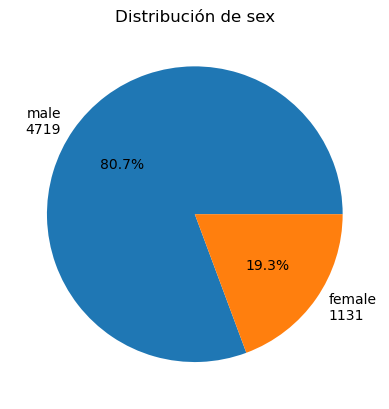

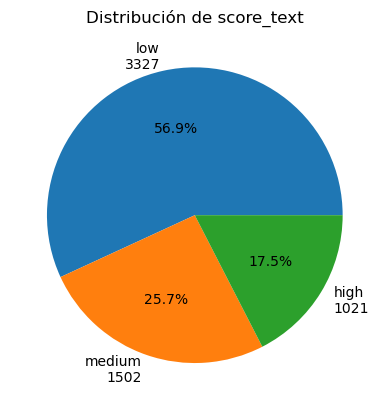

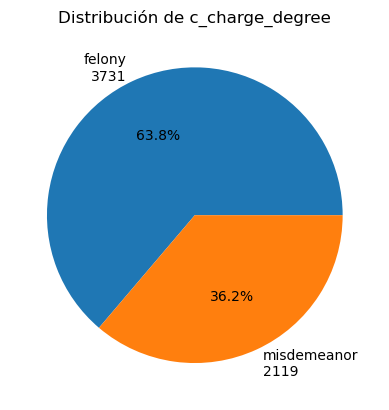

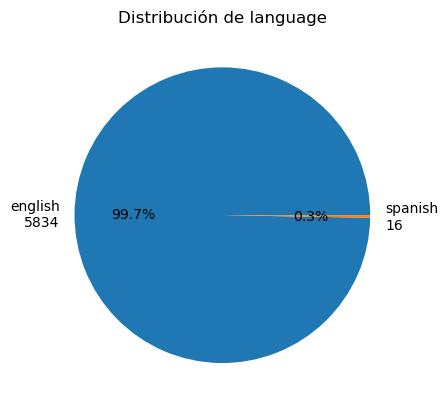

Media:
age                  35.122051
decile_score          4.323761
v_decile_score        3.586325
is_recid              0.408718
is_violent_recid      0.098632
two_year_recid        0.372821
priors_count          3.235214
start                12.370427
end                 599.131282
event                 0.322735
juv_fel_count         0.059487
juv_misd_count        0.086667
juv_other_count       0.100684
rawscore             -2.412280
days_in_jail         18.634156
juv_priors_count      0.246838
dtype: float64


Mediana:
age                  32.000000
decile_score          4.000000
v_decile_score        3.000000
is_recid              0.000000
is_violent_recid      0.000000
two_year_recid        0.000000
priors_count          1.000000
start                 0.000000
end                 737.000000
event                 0.000000
juv_fel_count         0.000000
juv_misd_count        0.000000
juv_other_count       0.000000
rawscore             -2.380000
days_in_jail          1.242031
juv_pr

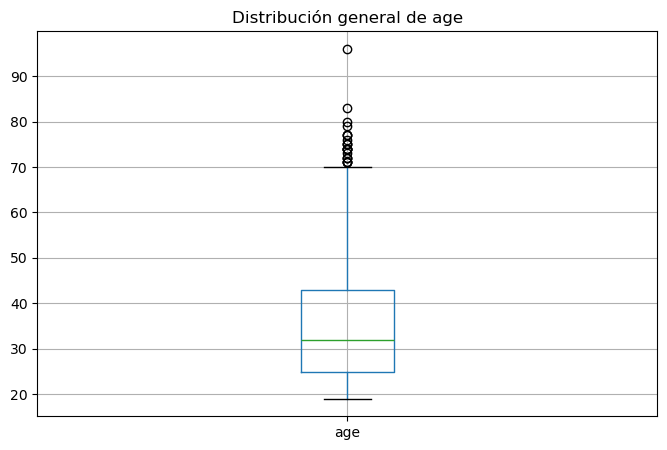

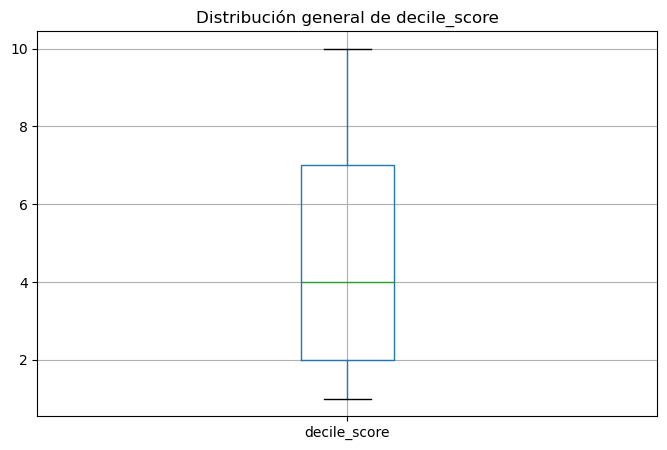

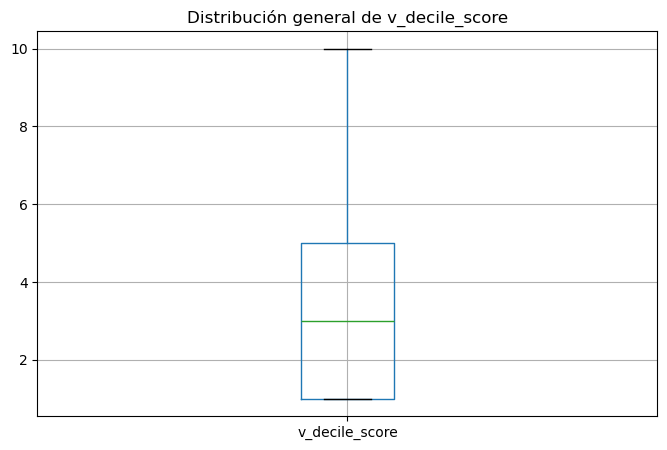

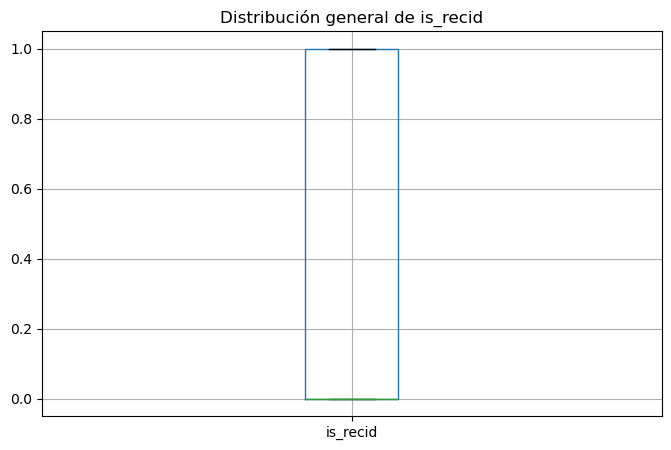

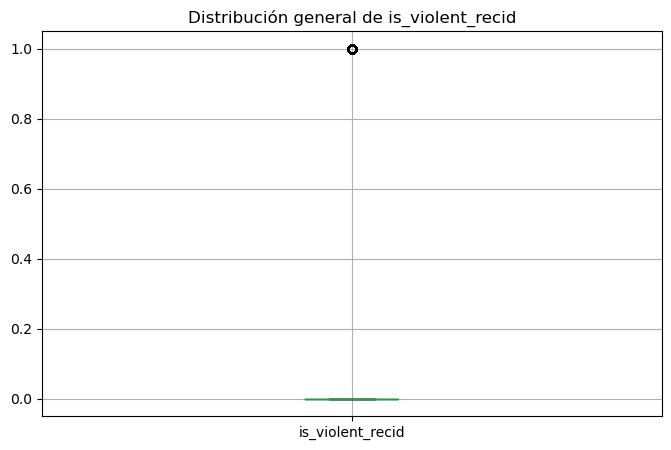

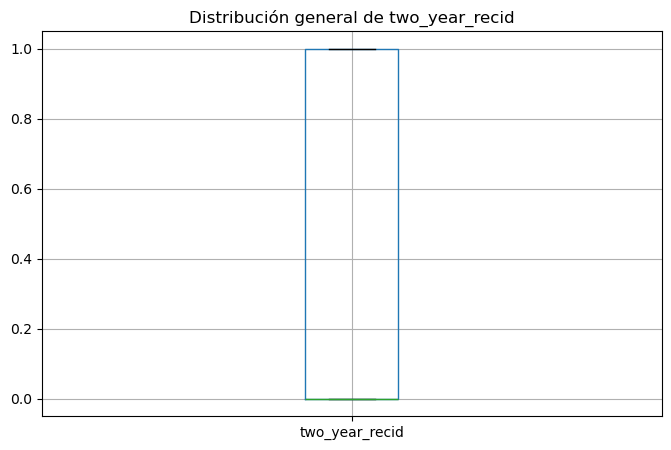

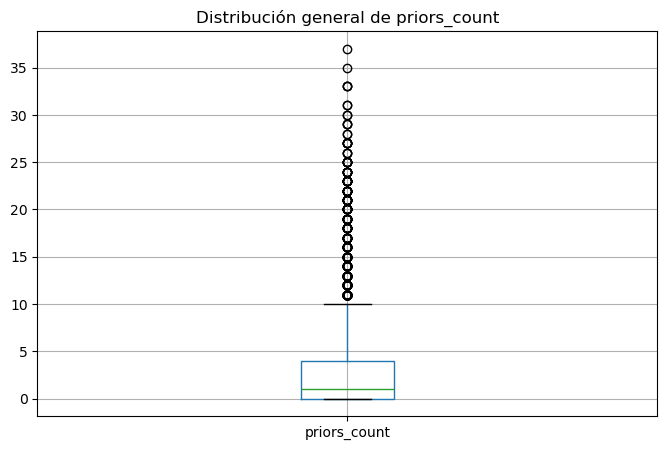

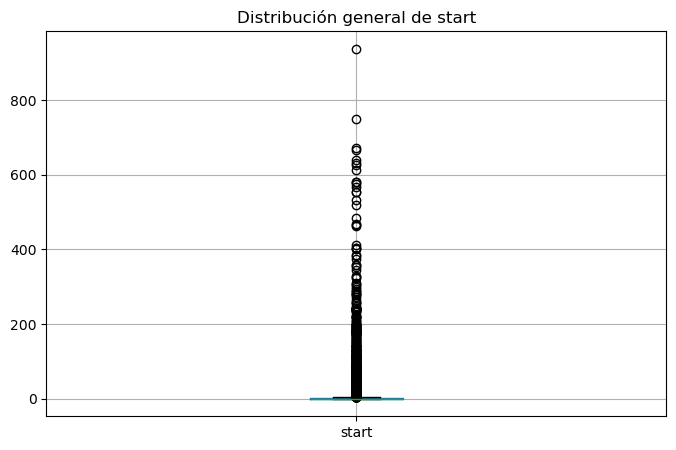

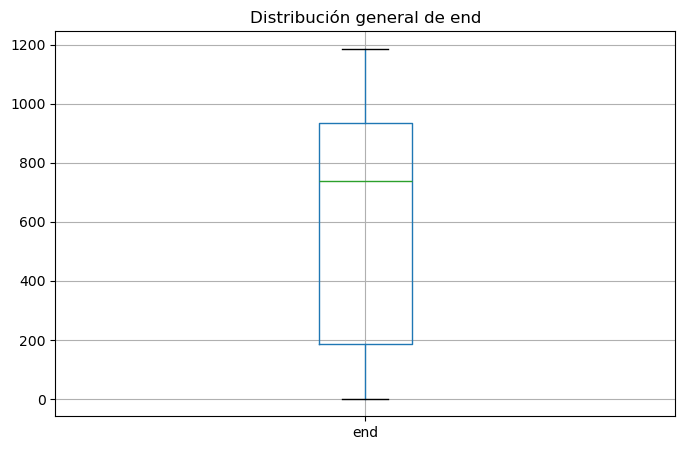

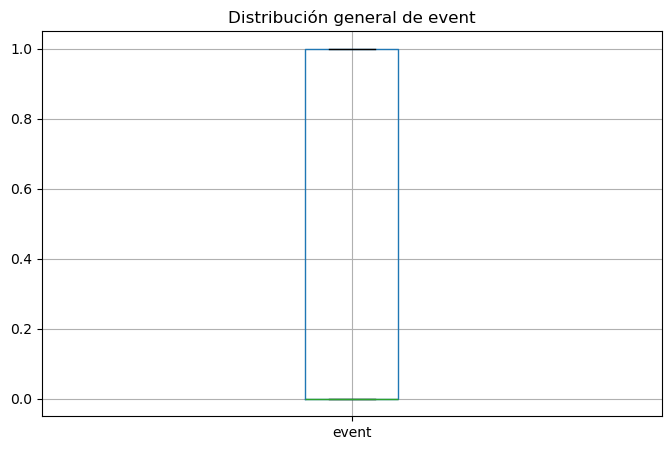

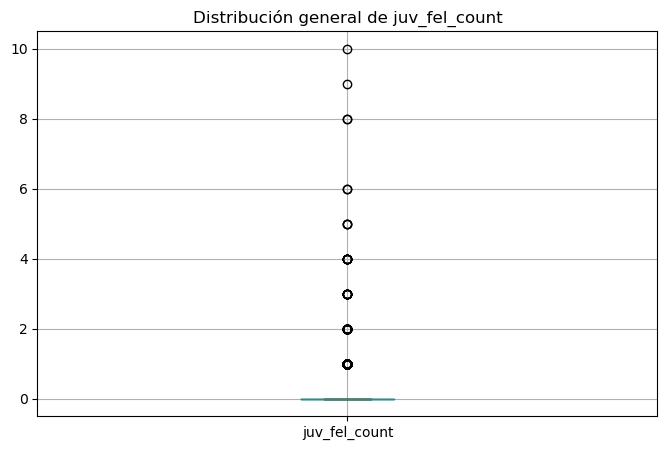

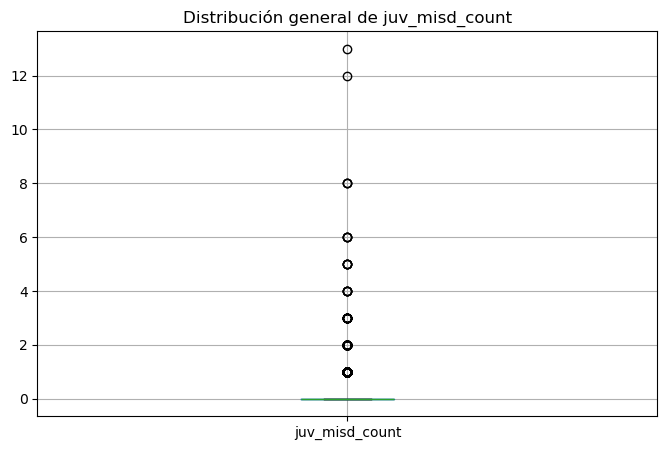

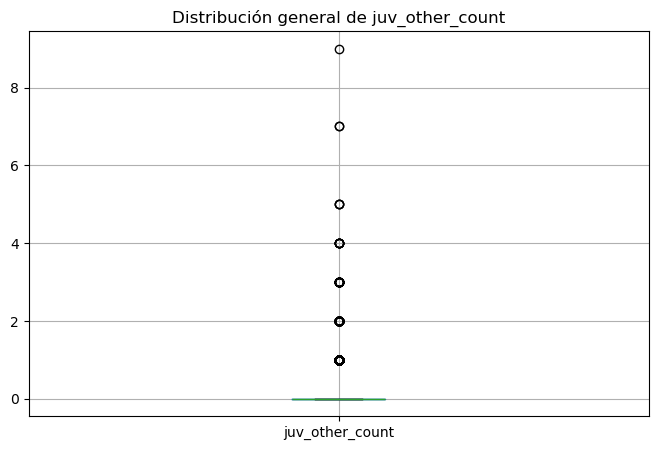

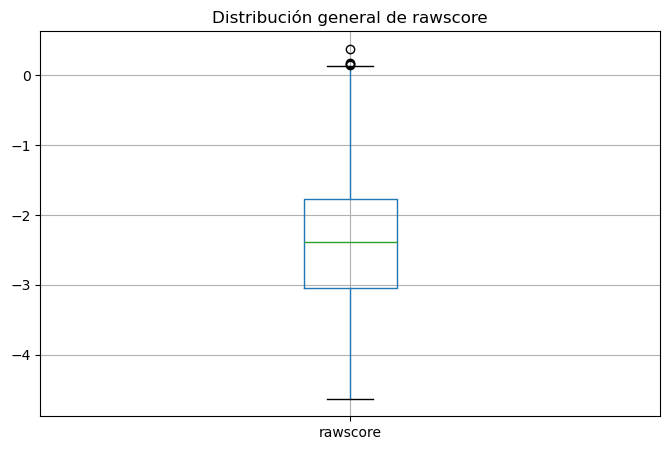

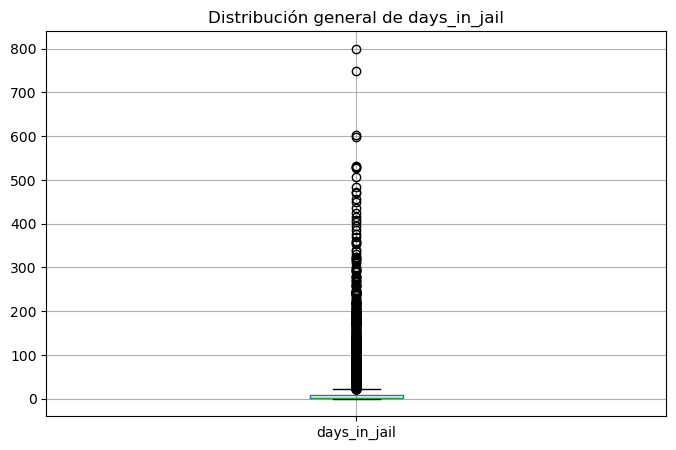

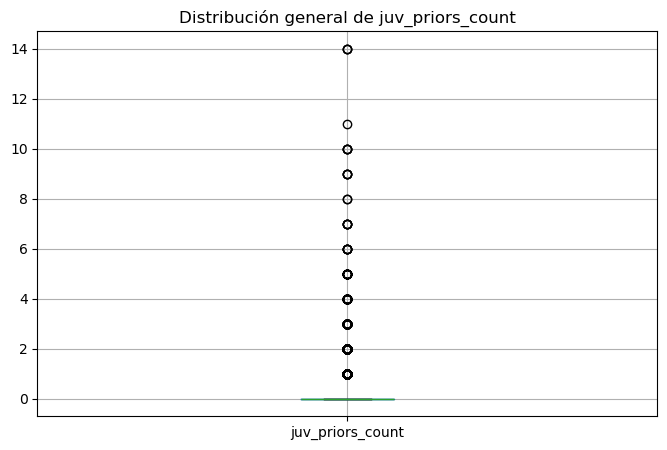

# Análisis bivariable

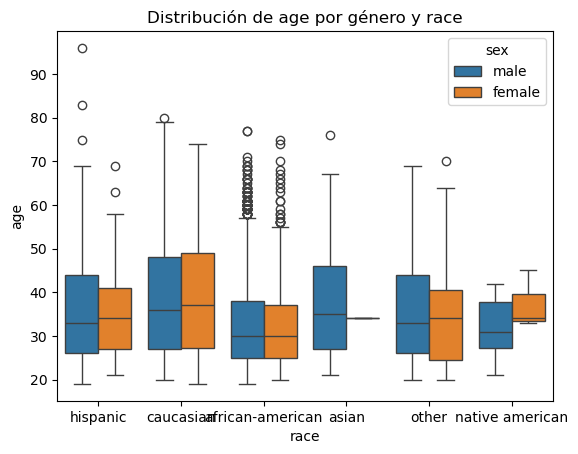

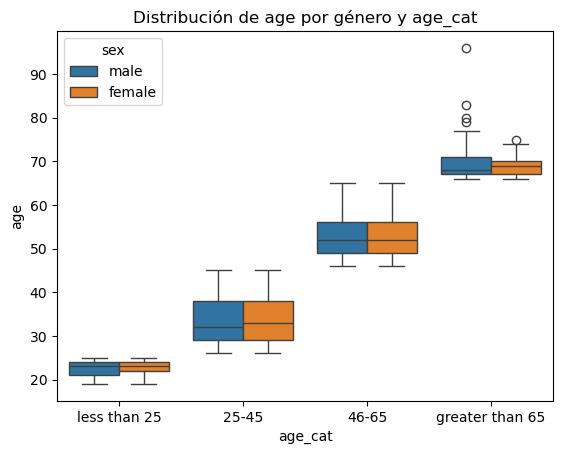

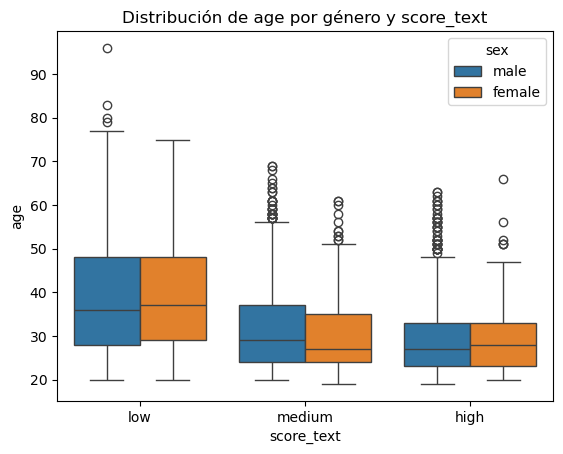

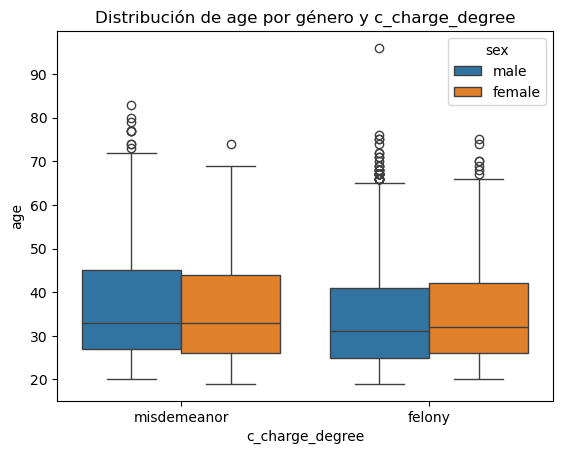

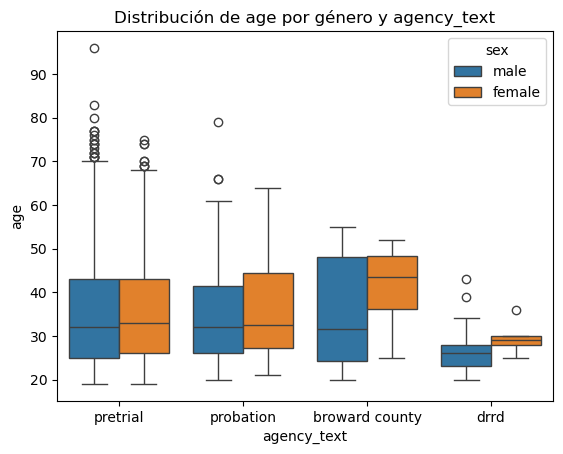

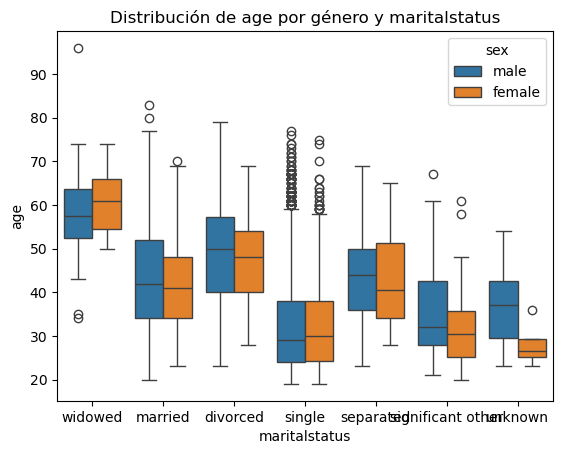

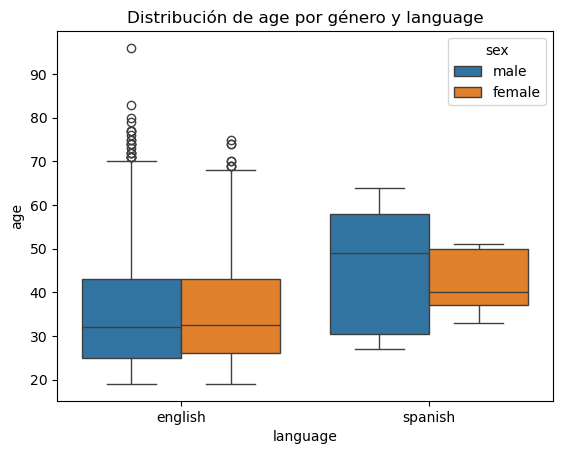

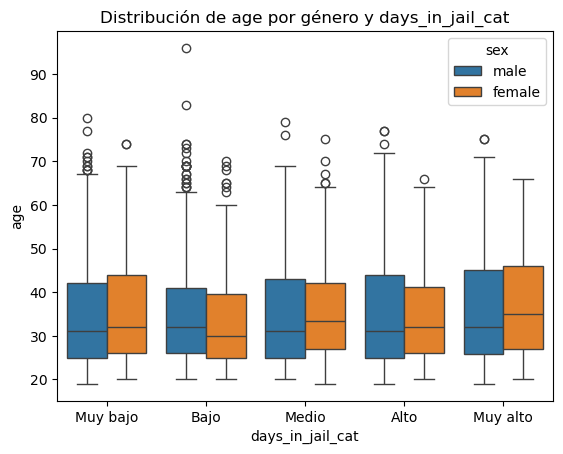

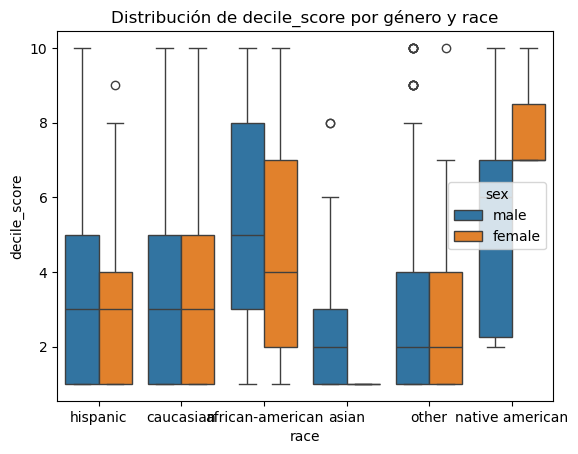

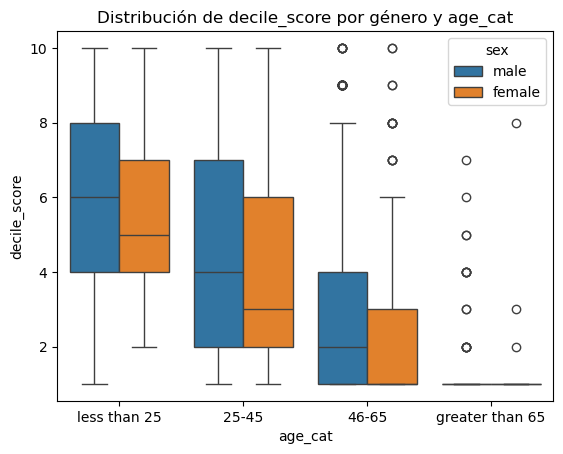

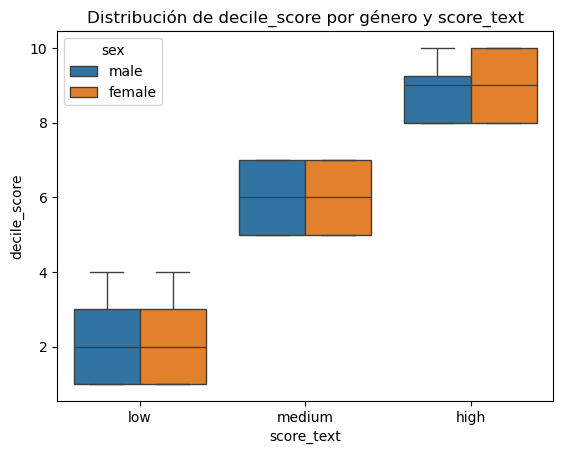

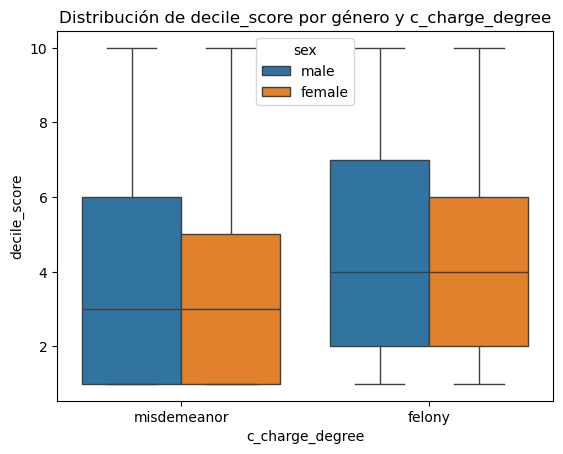

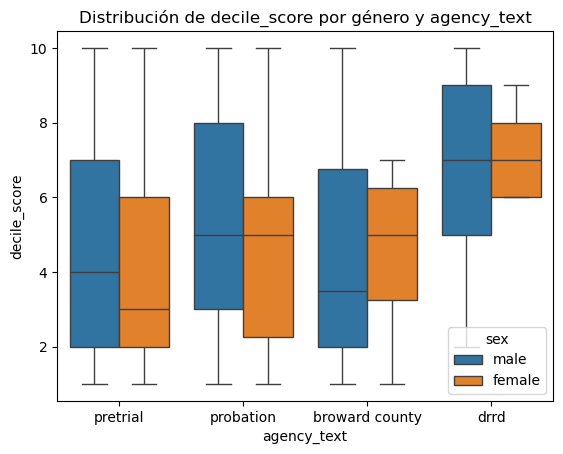

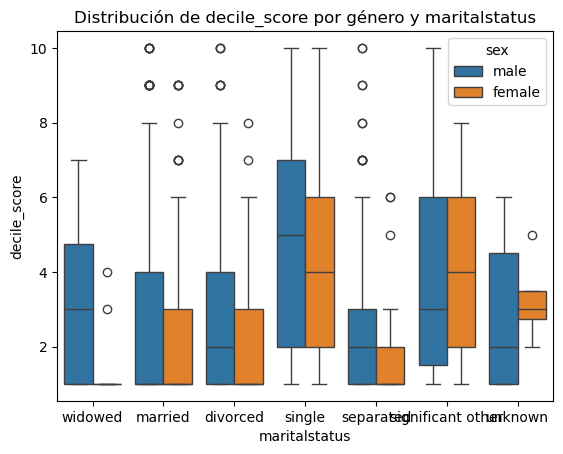

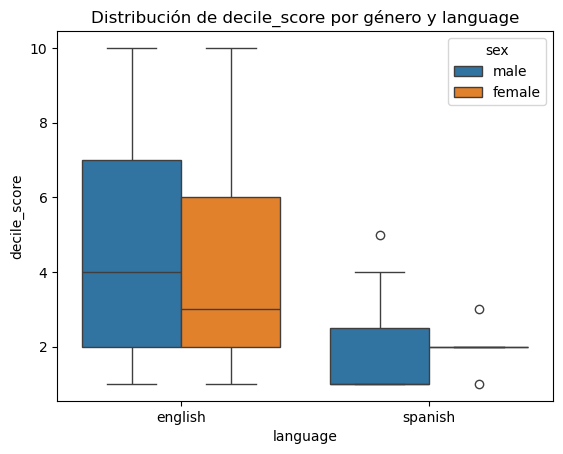

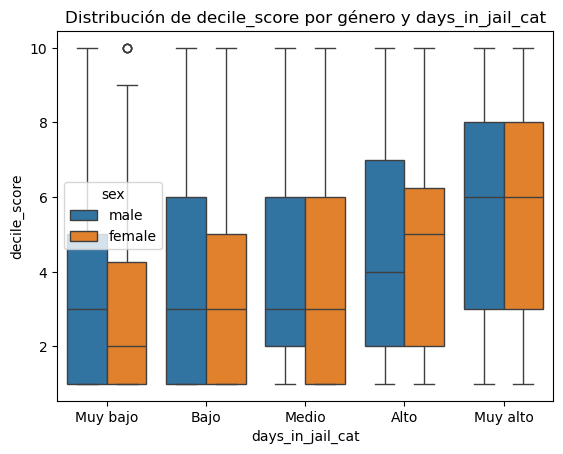

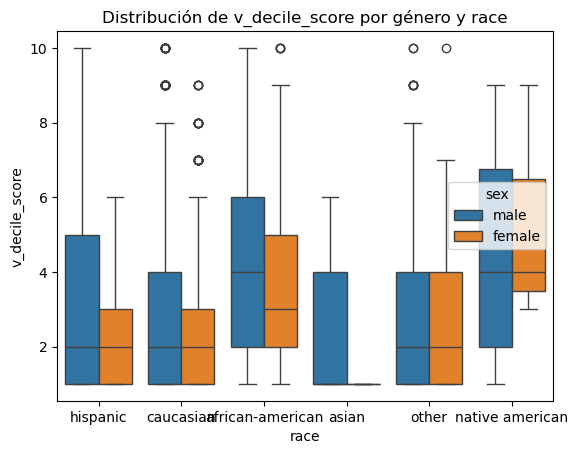

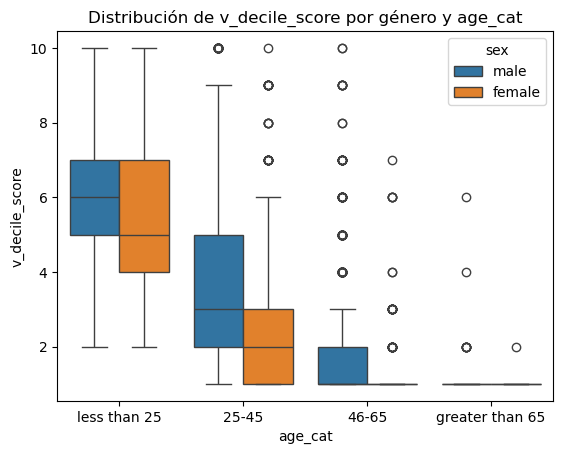

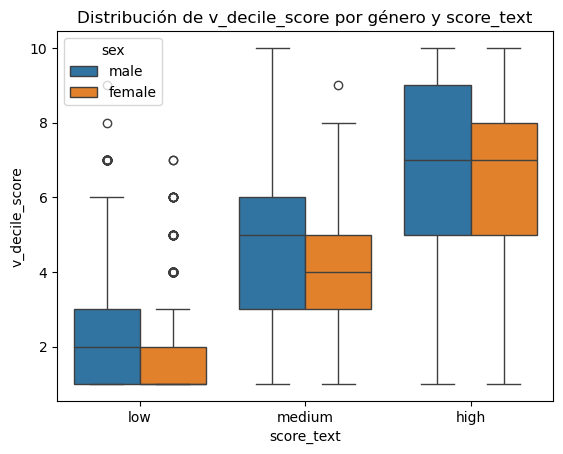

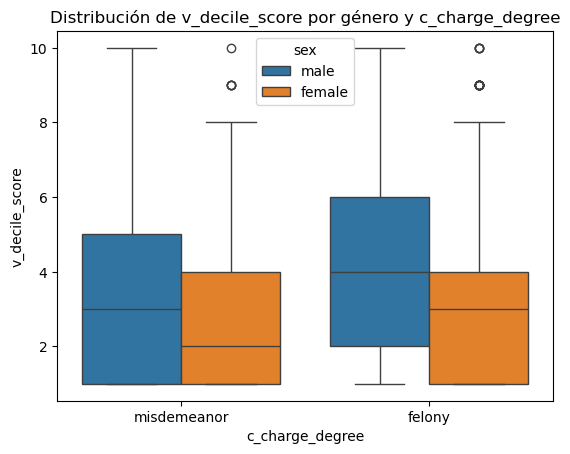

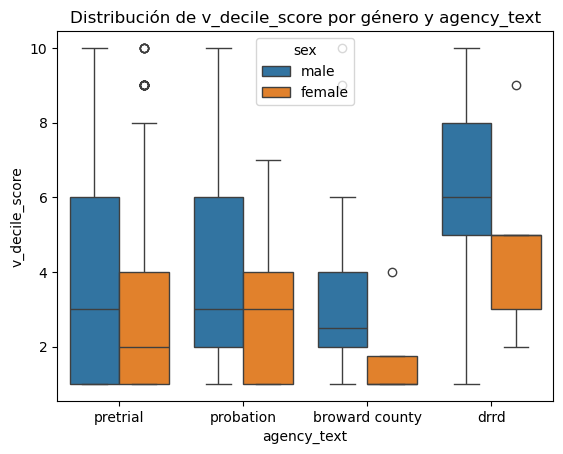

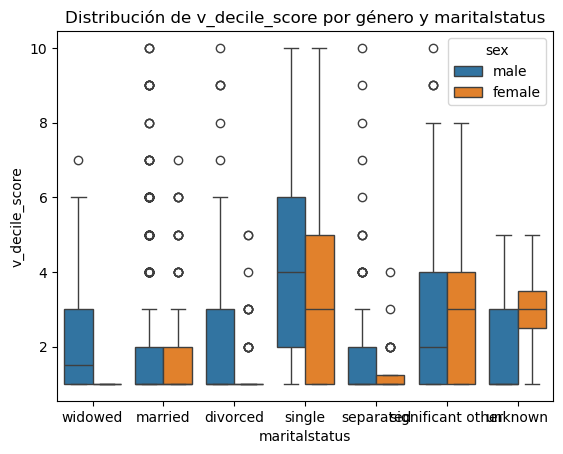

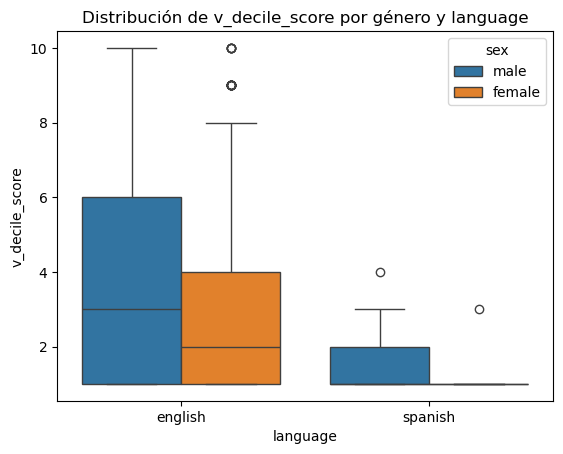

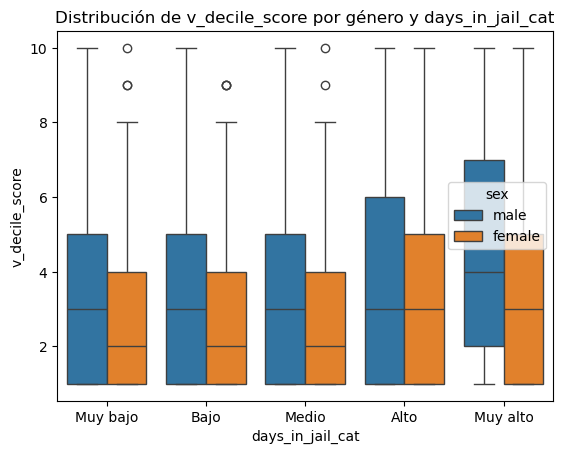

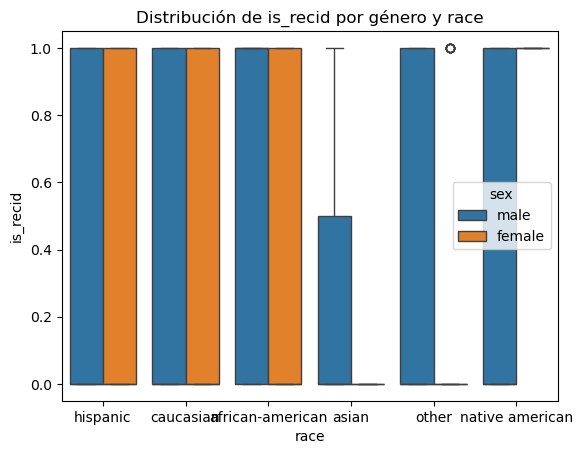

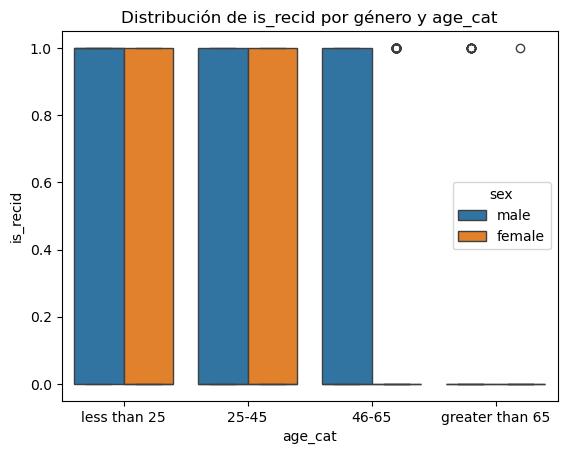

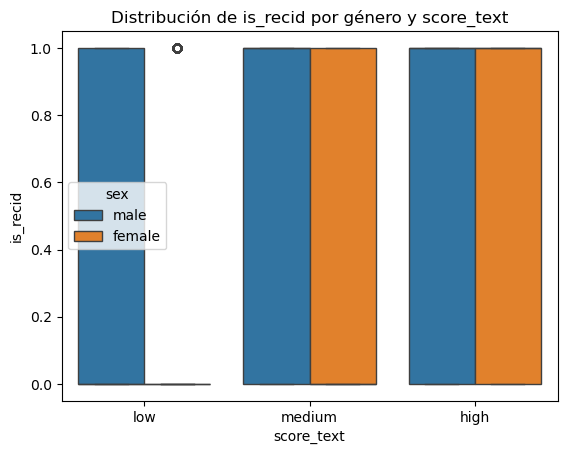

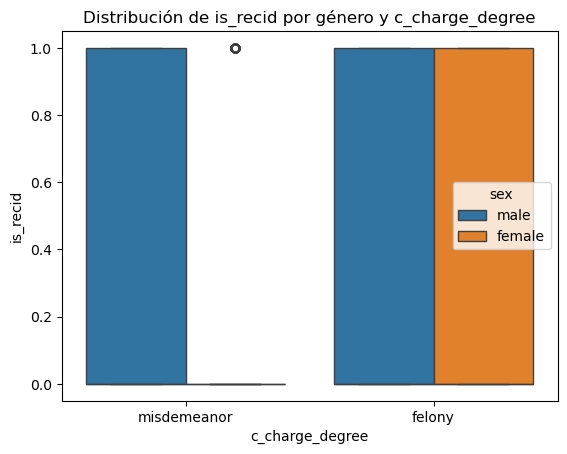

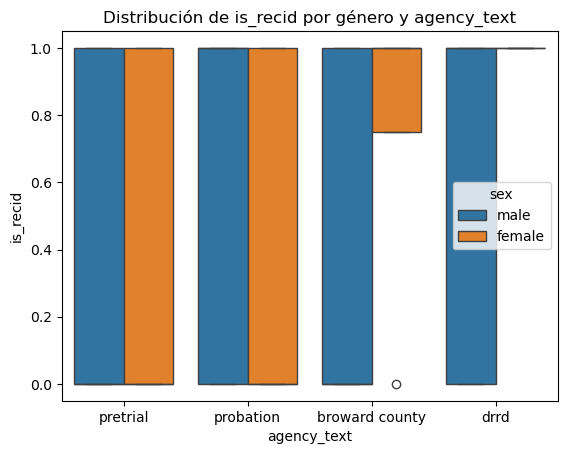

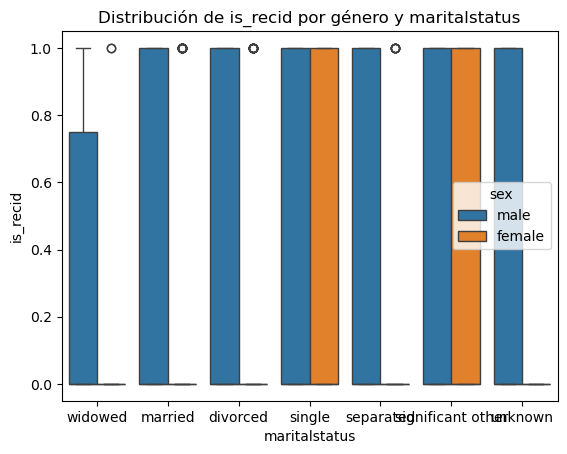

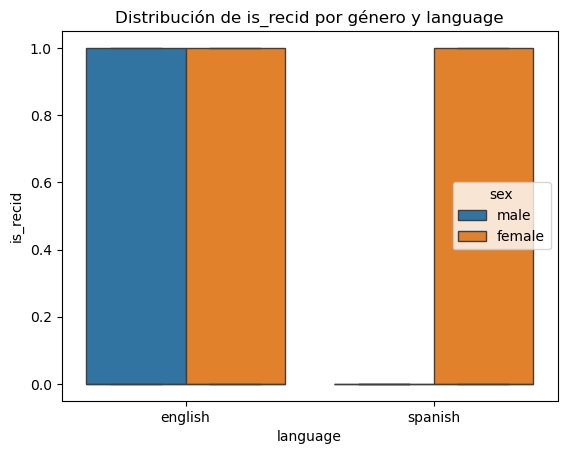

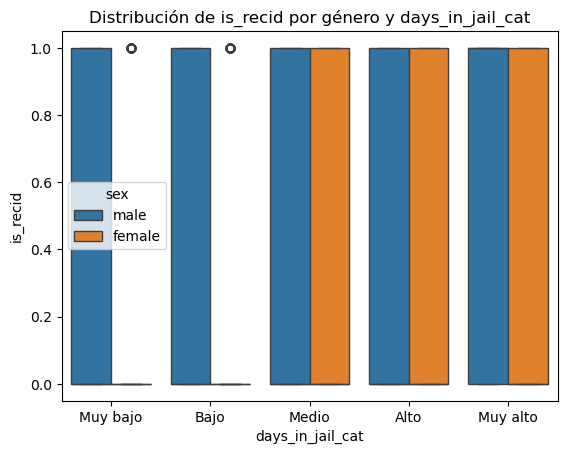

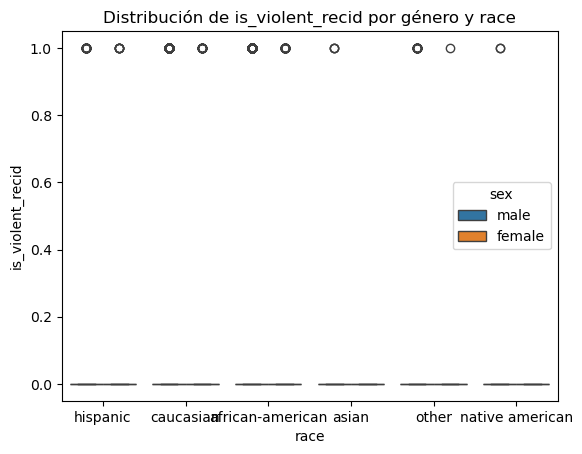

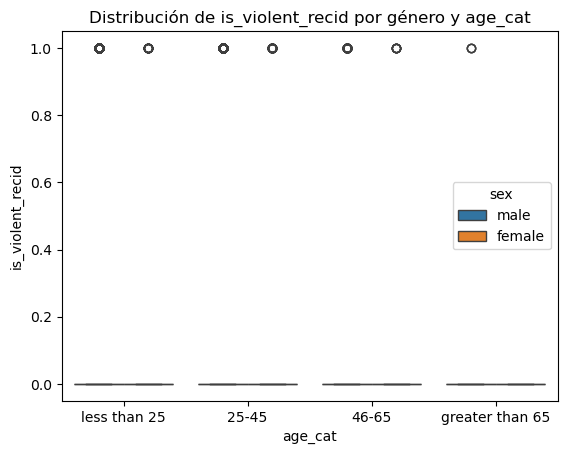

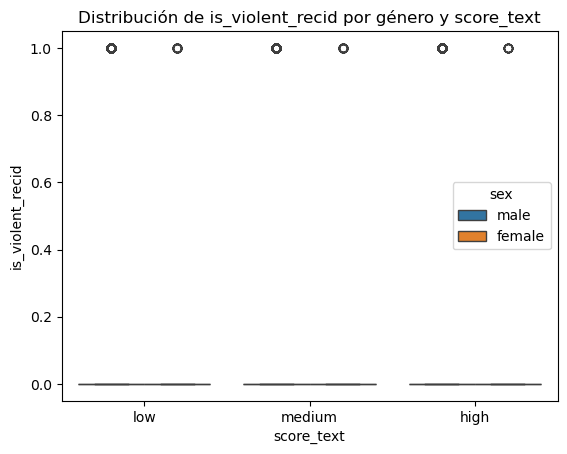

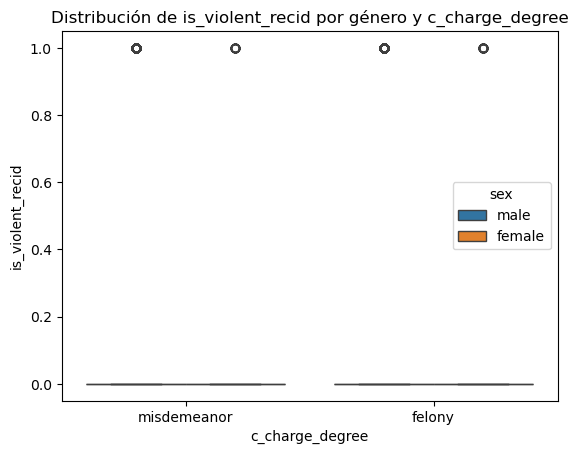

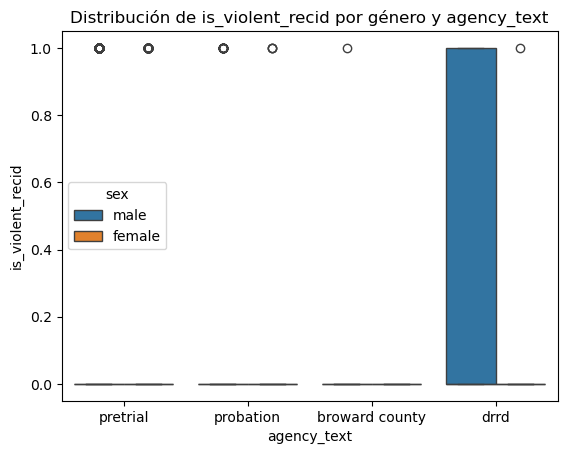

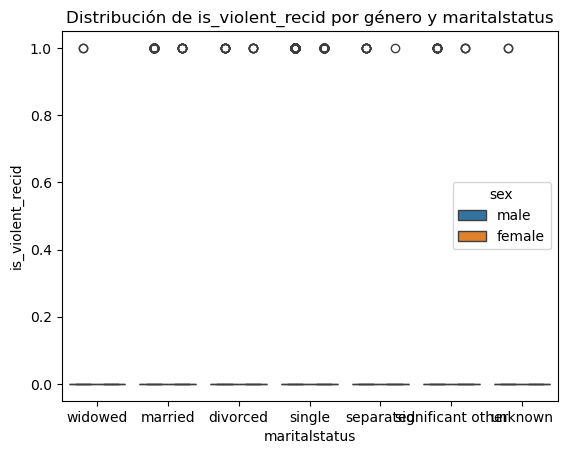

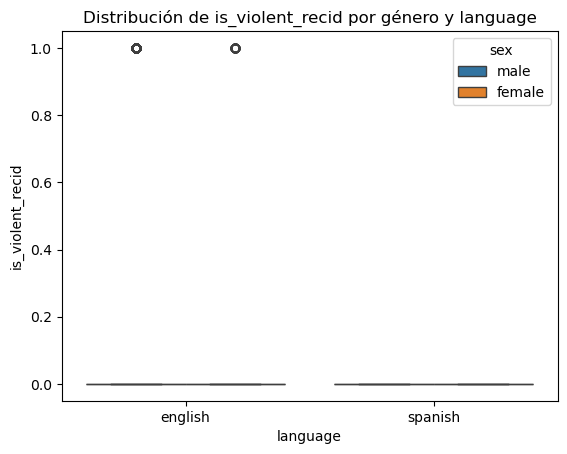

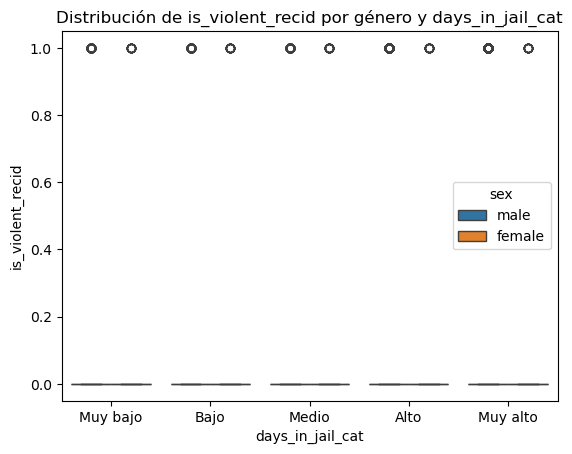

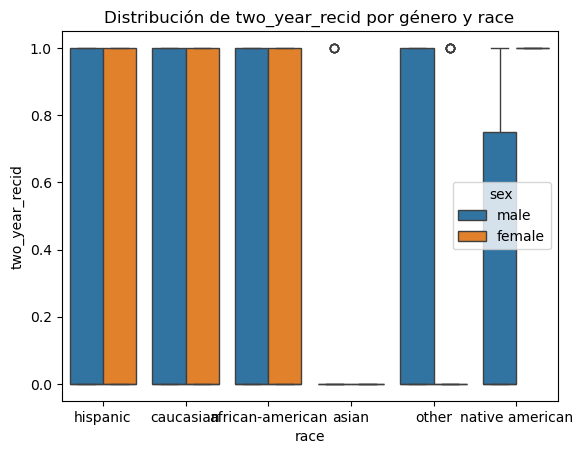

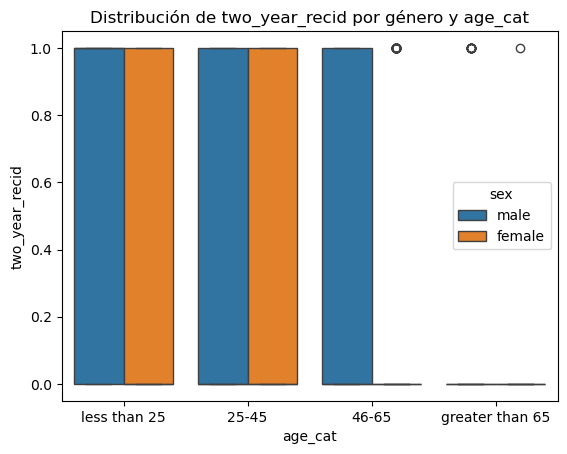

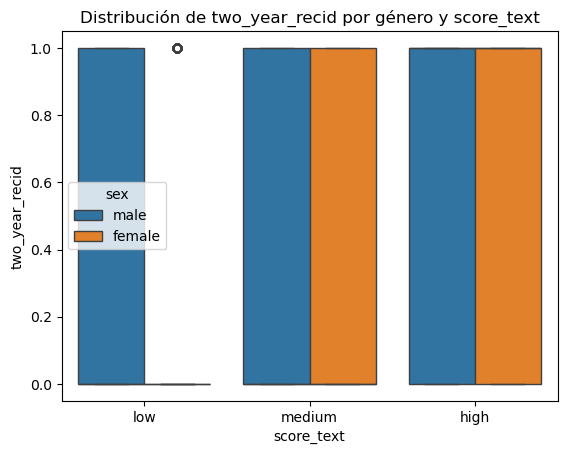

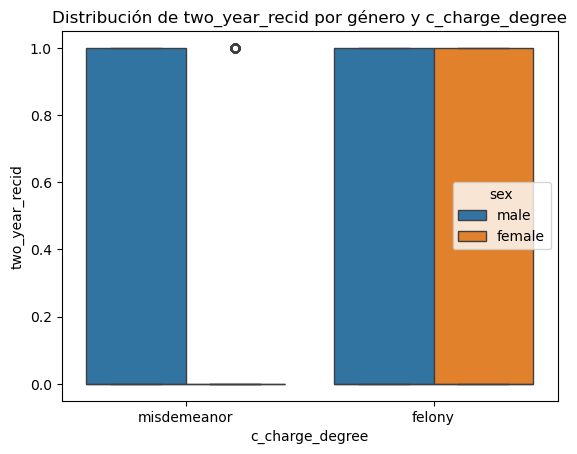

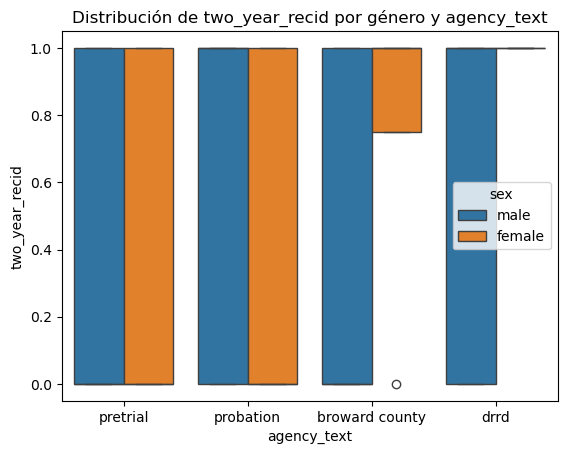

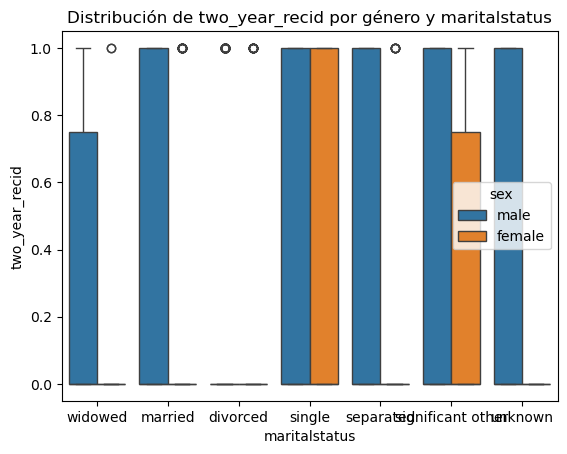

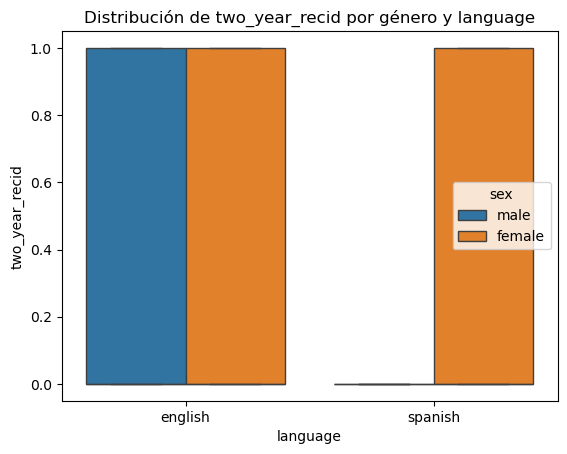

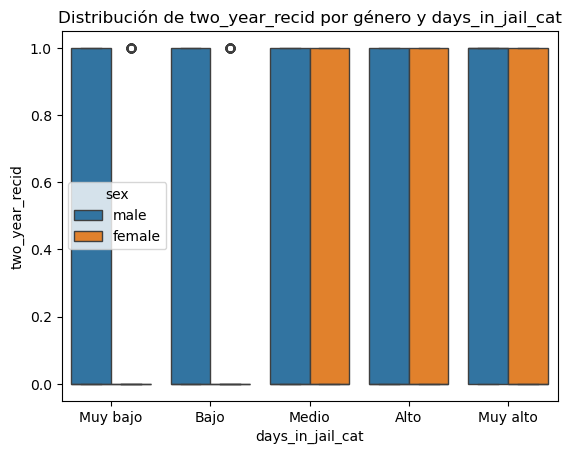

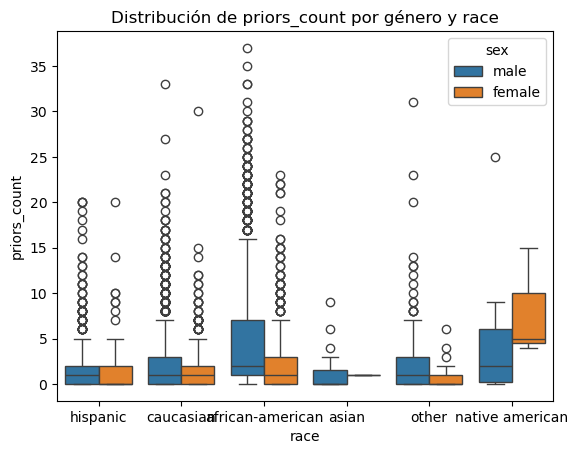

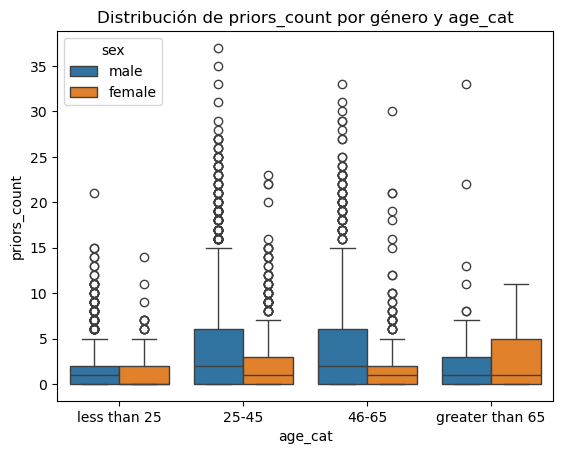

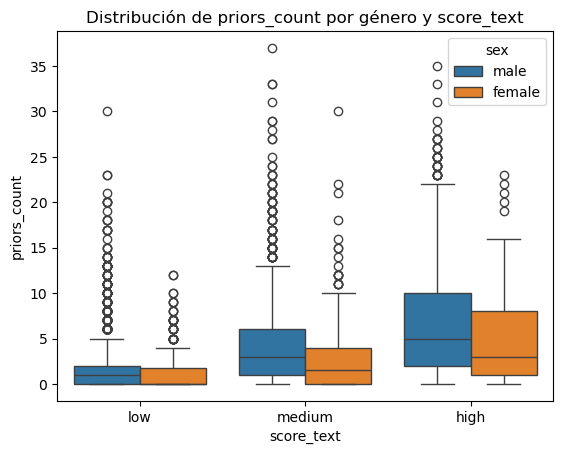

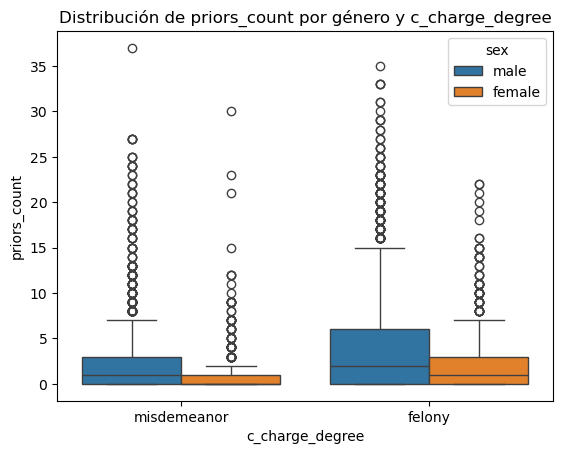

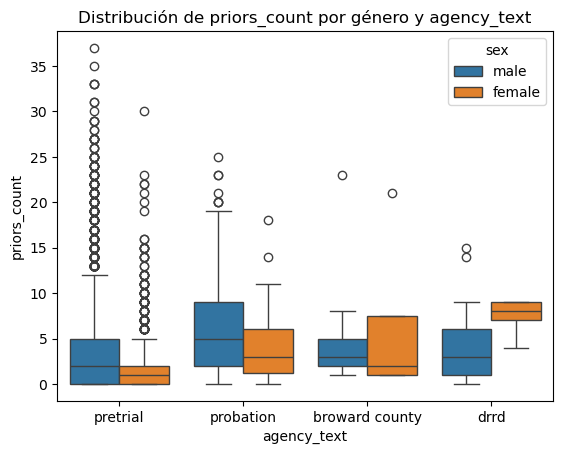

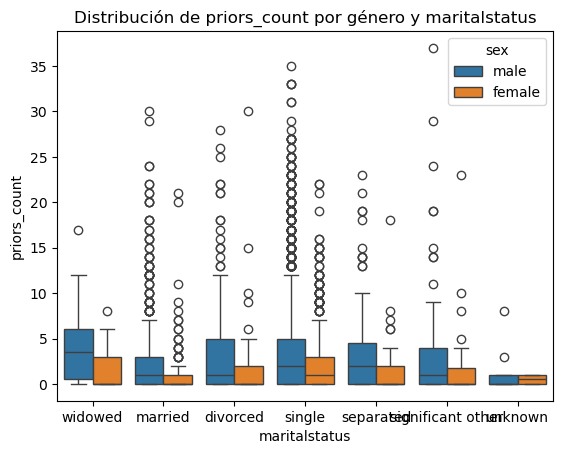

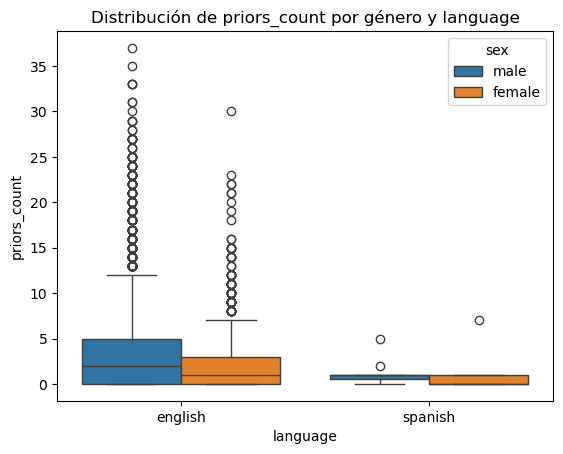

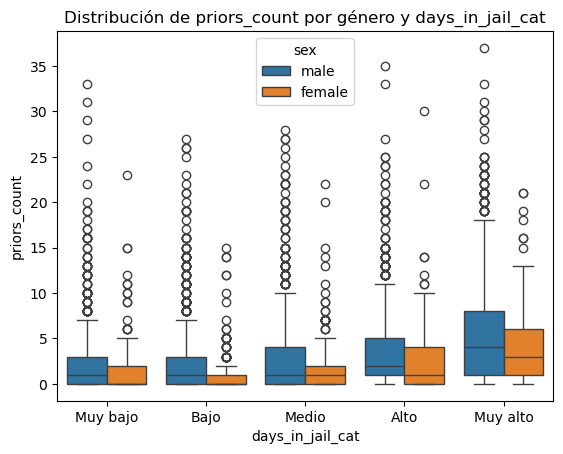

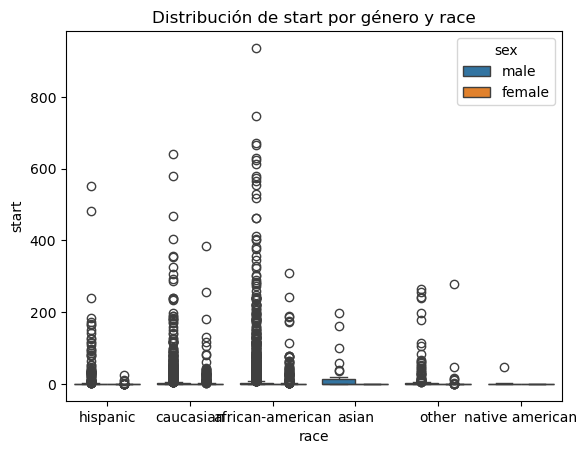

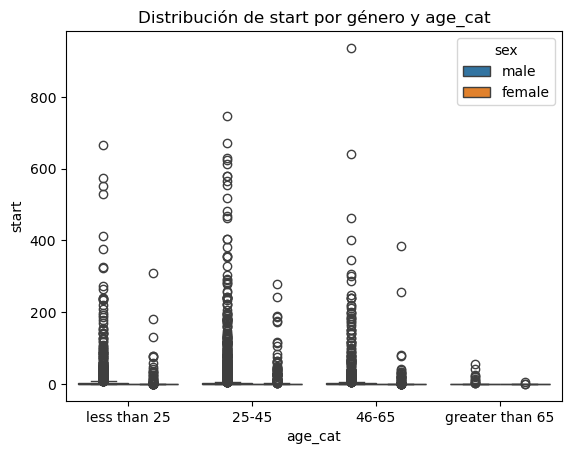

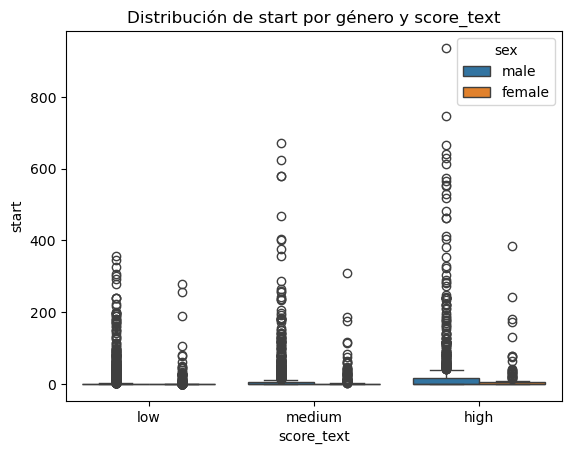

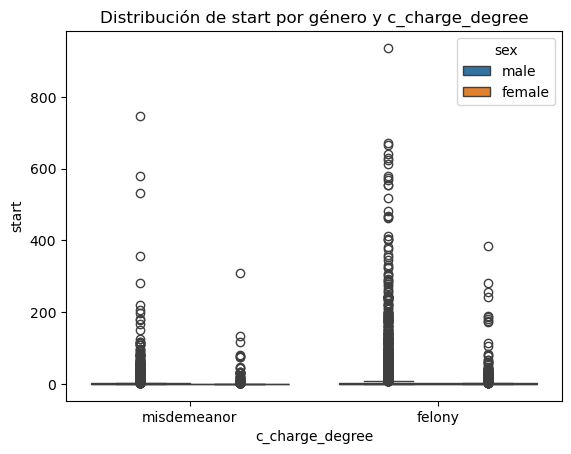

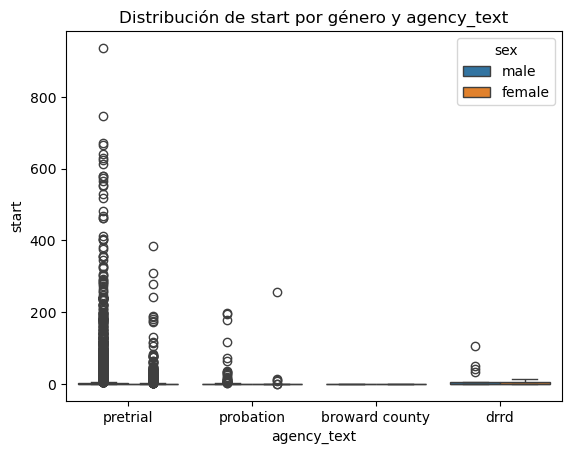

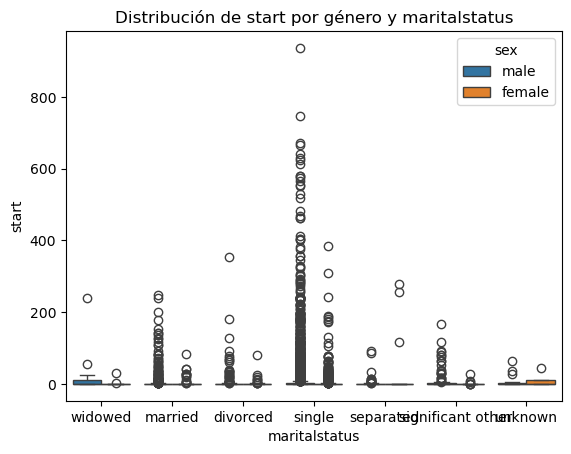

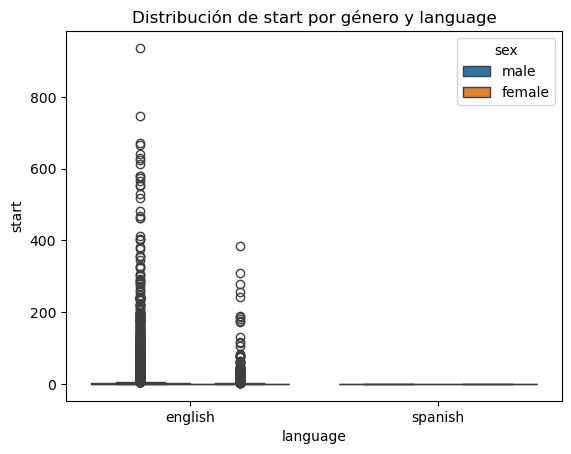

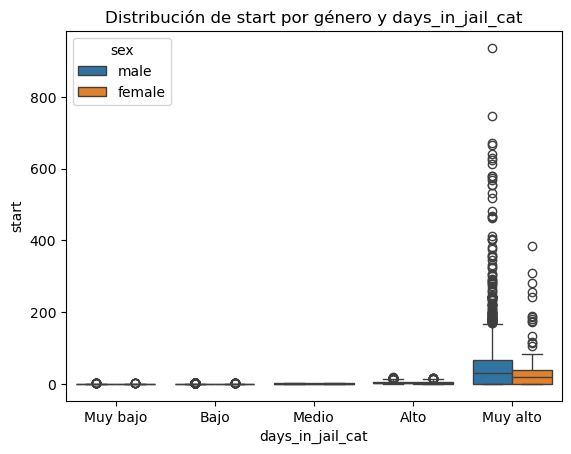

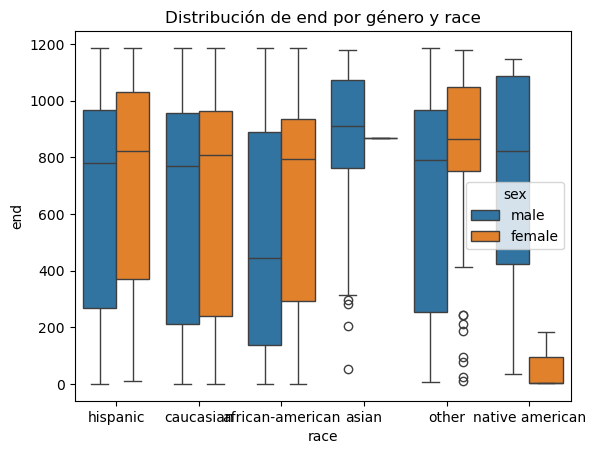

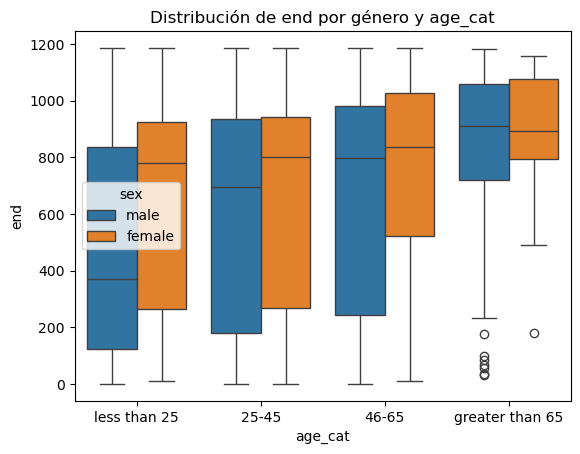

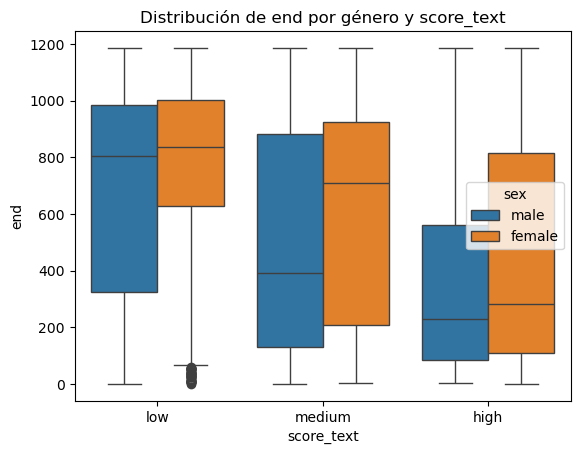

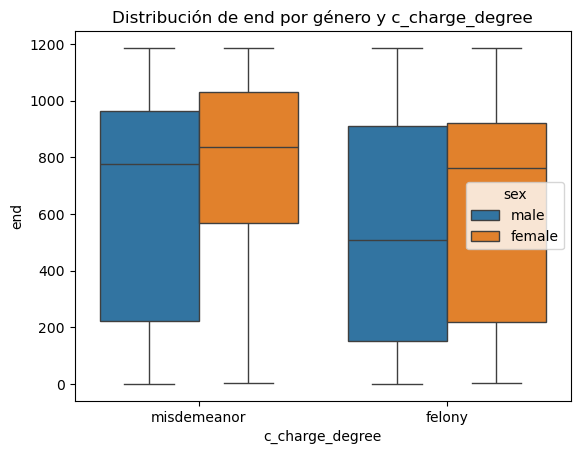

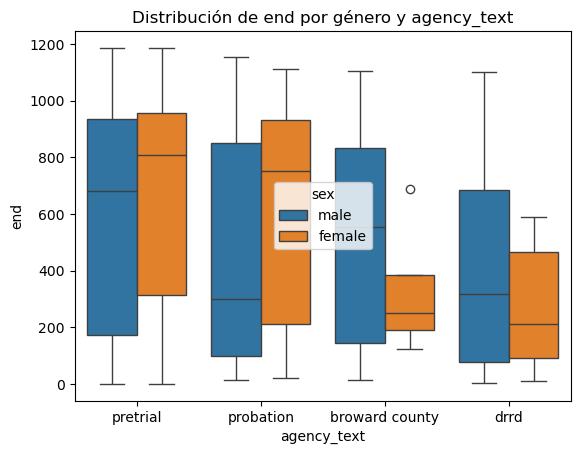

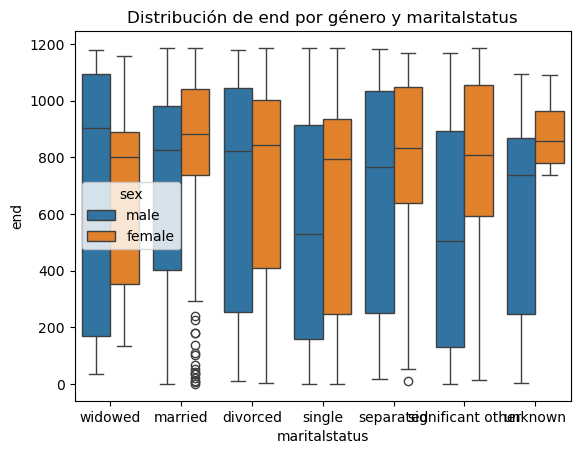

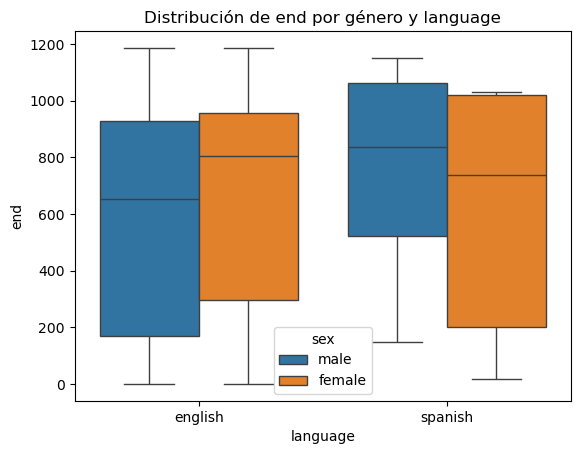

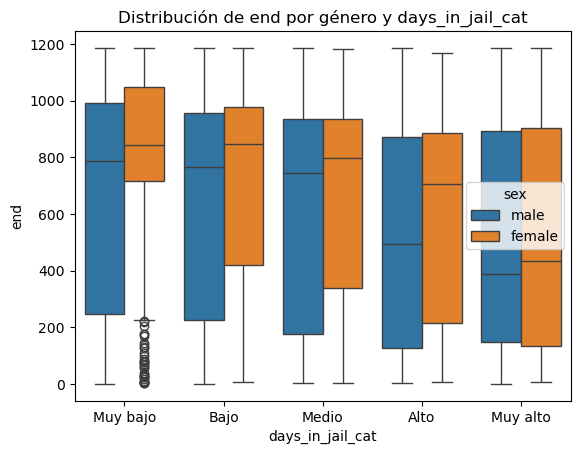

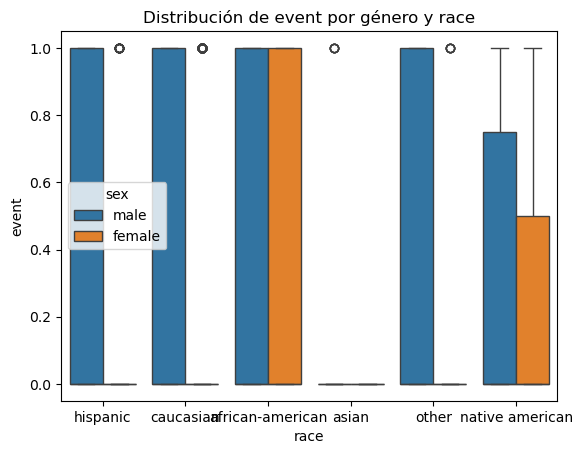

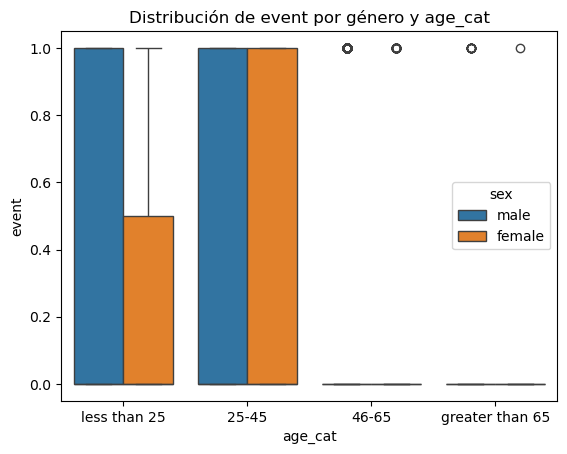

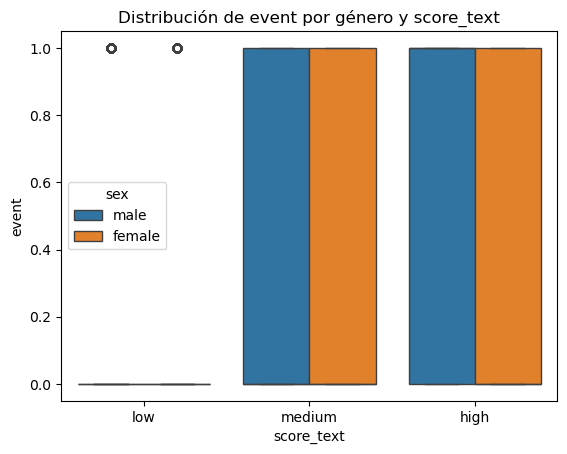

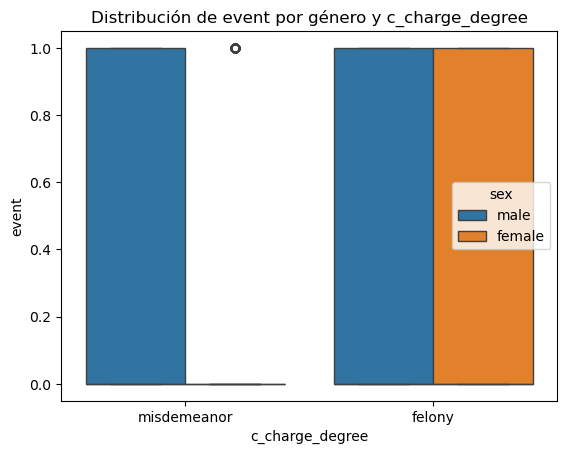

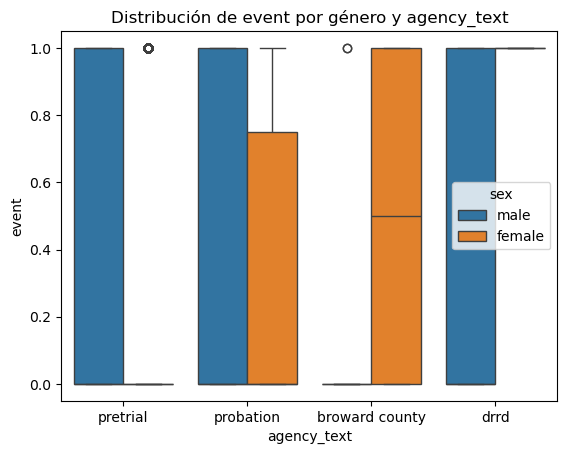

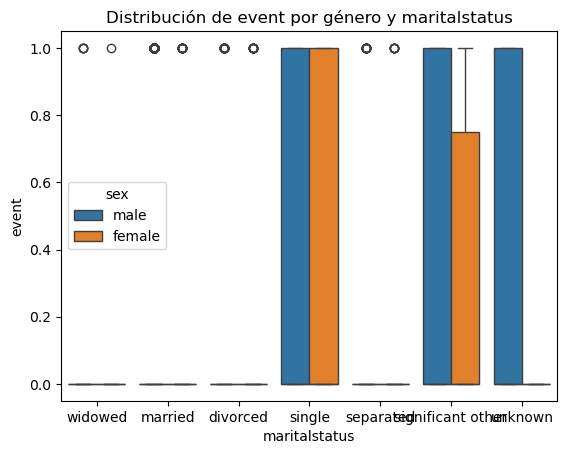

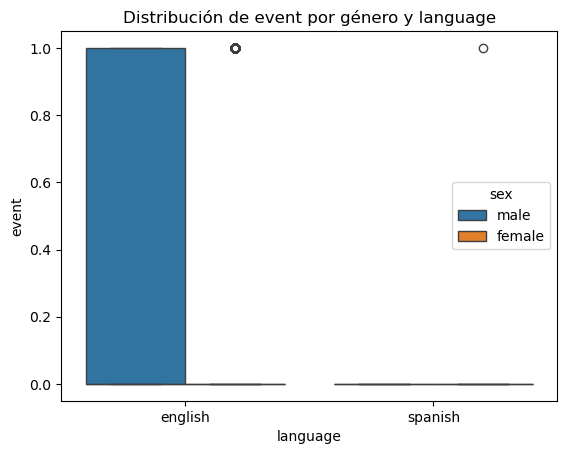

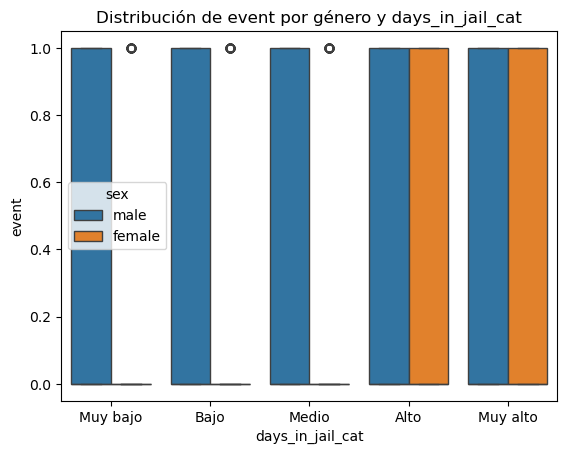

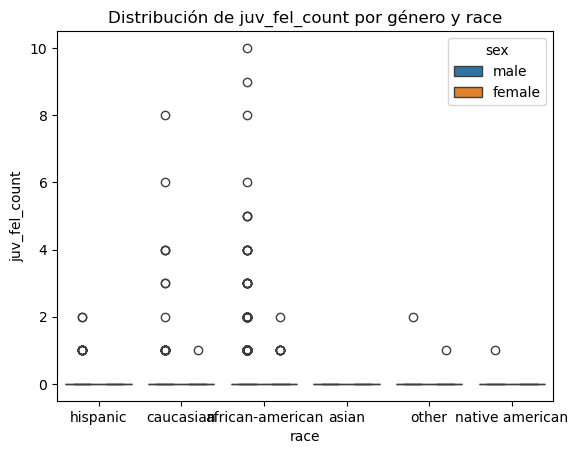

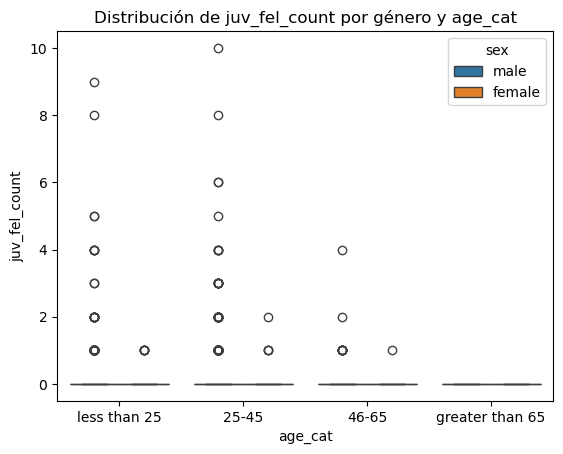

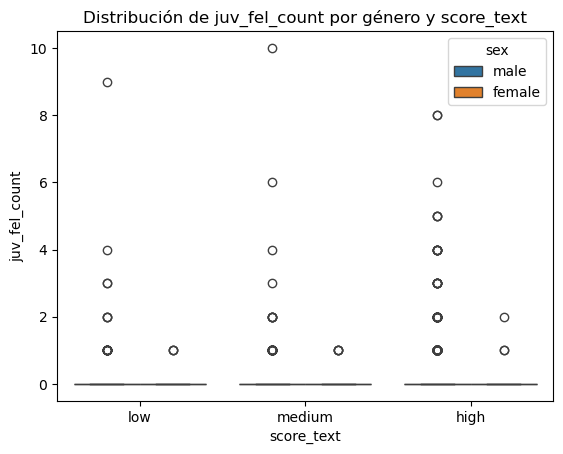

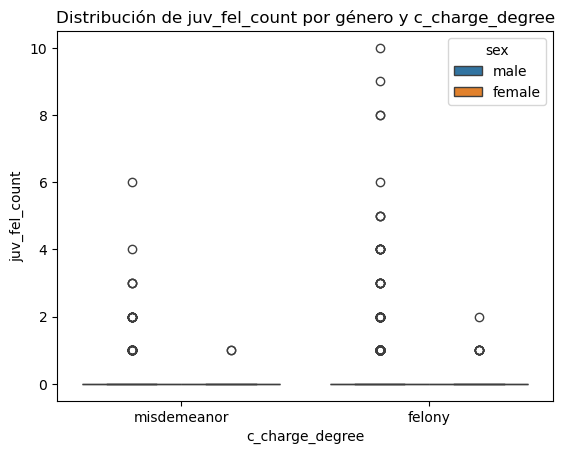

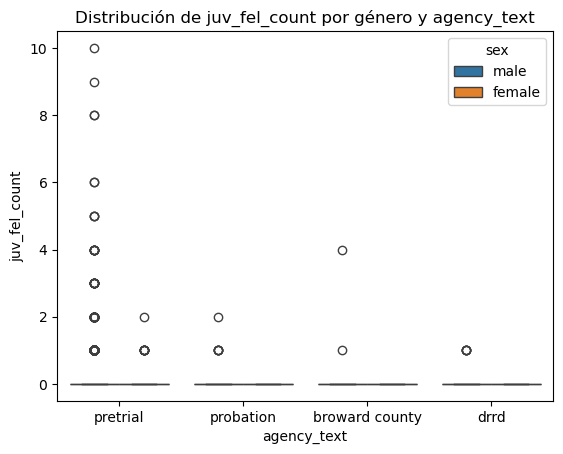

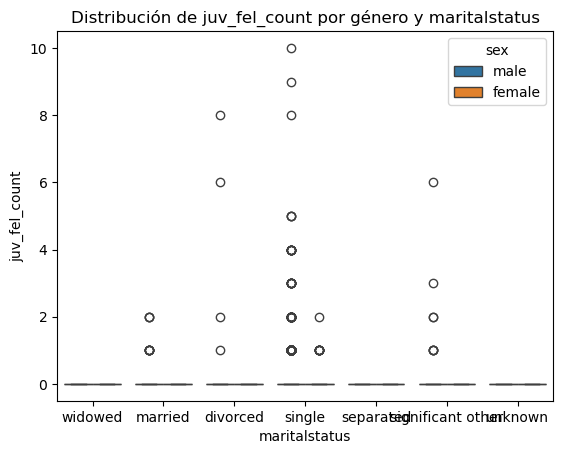

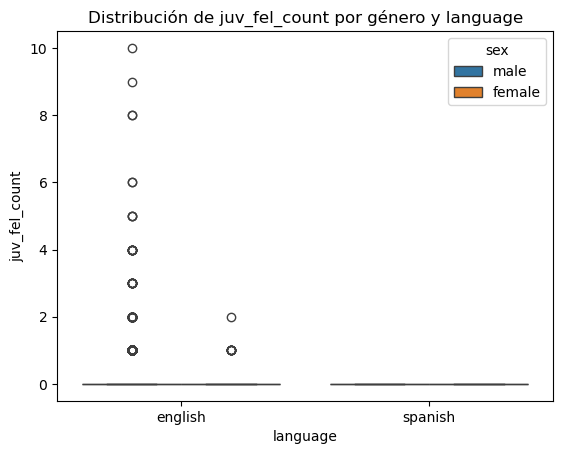

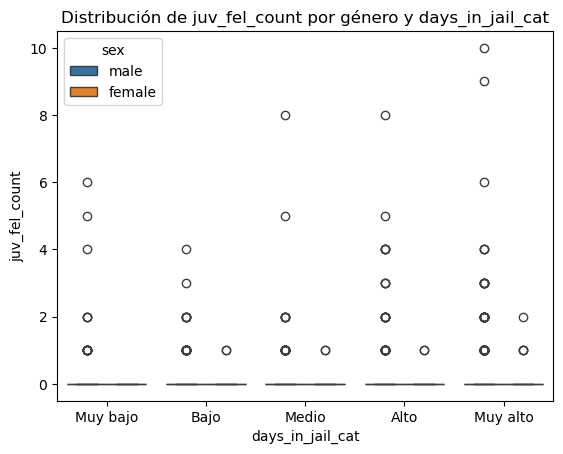

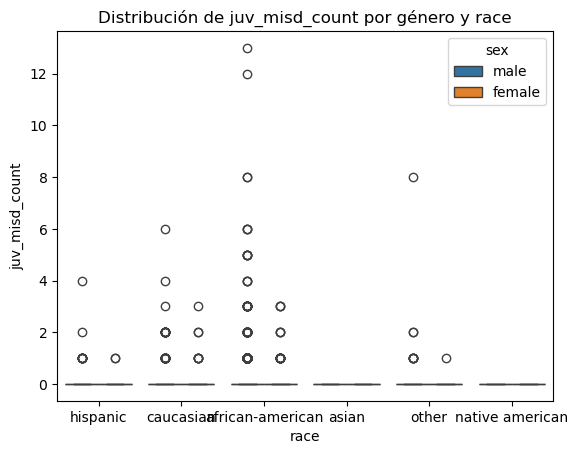

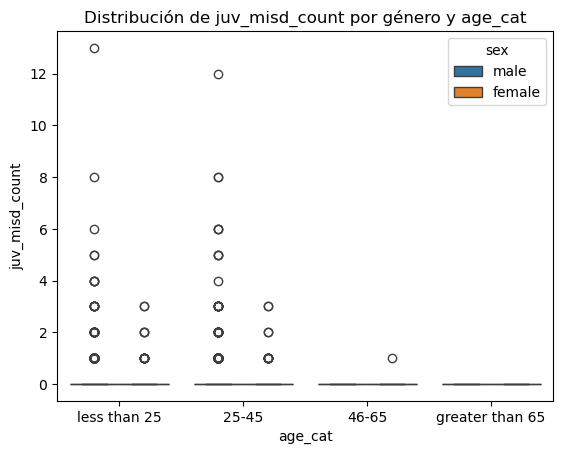

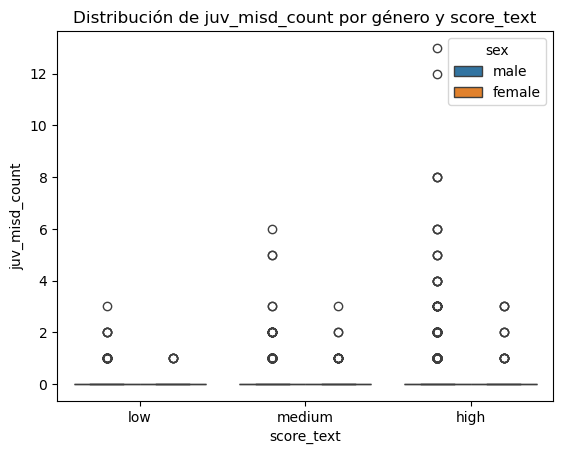

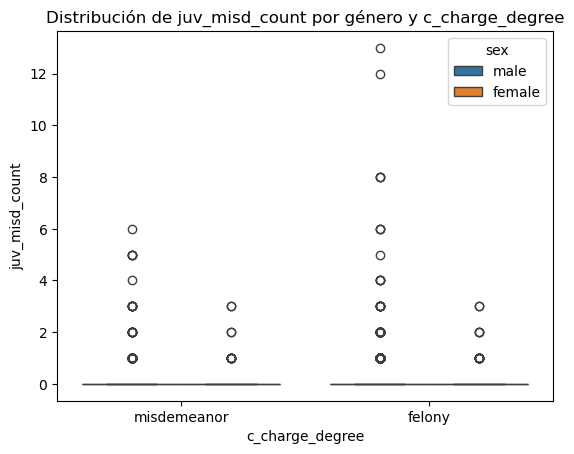

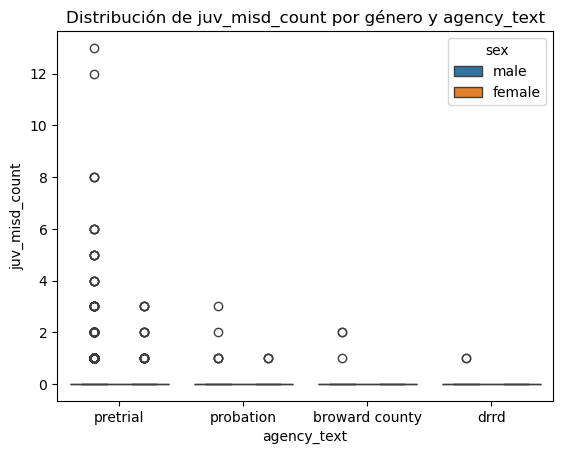

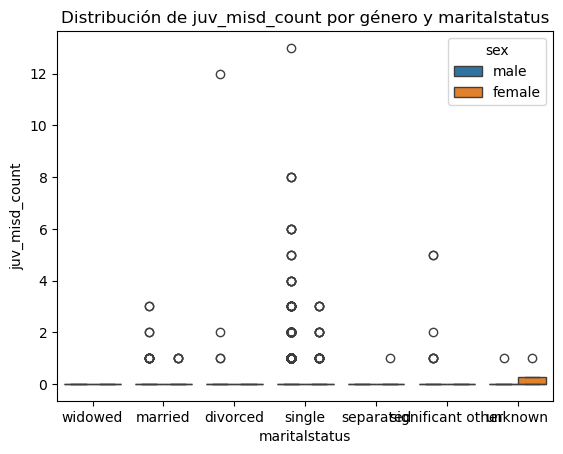

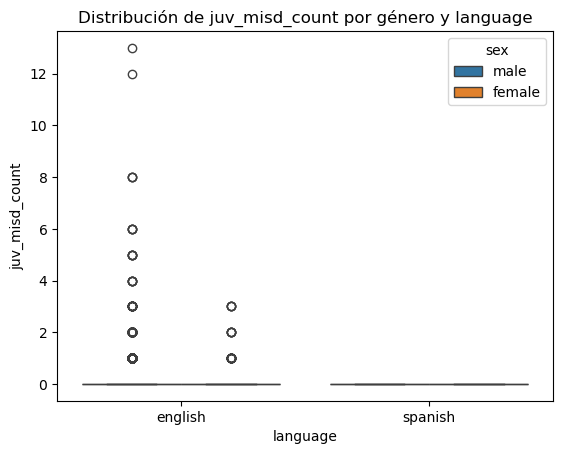

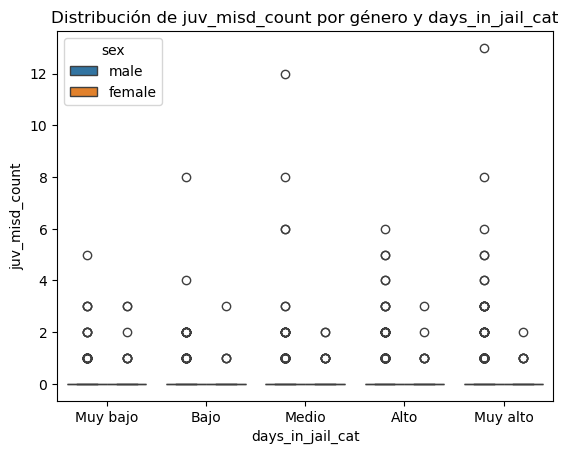

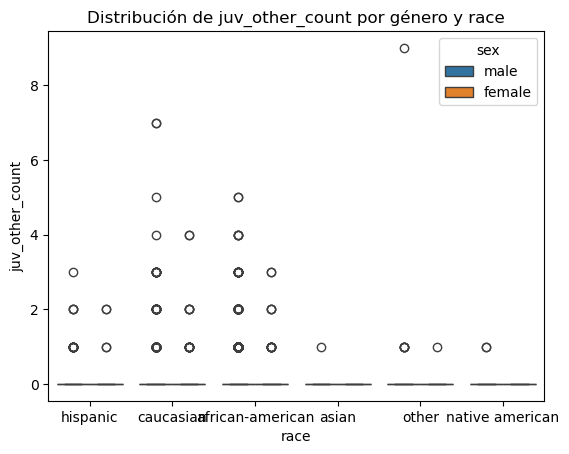

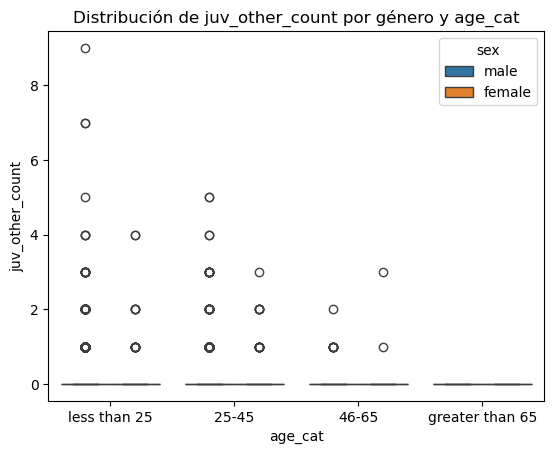

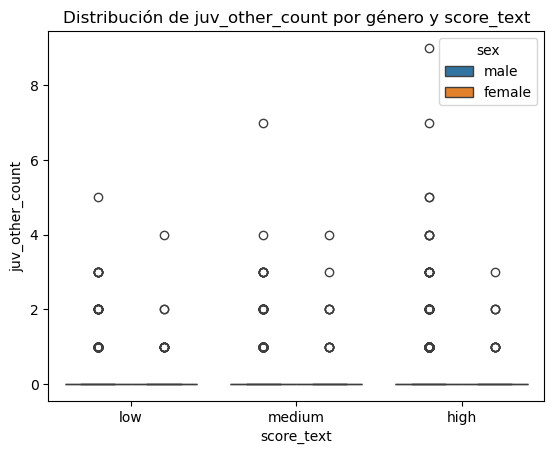

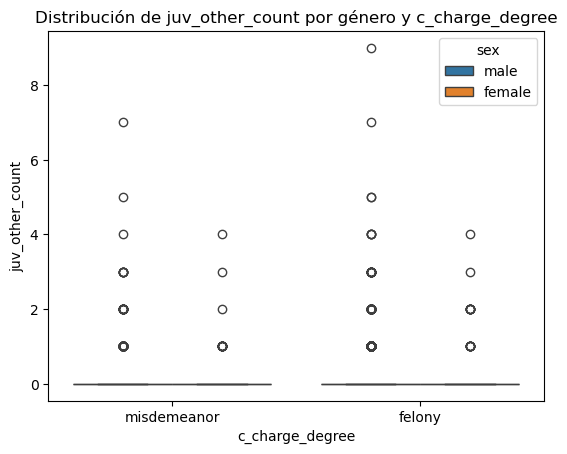

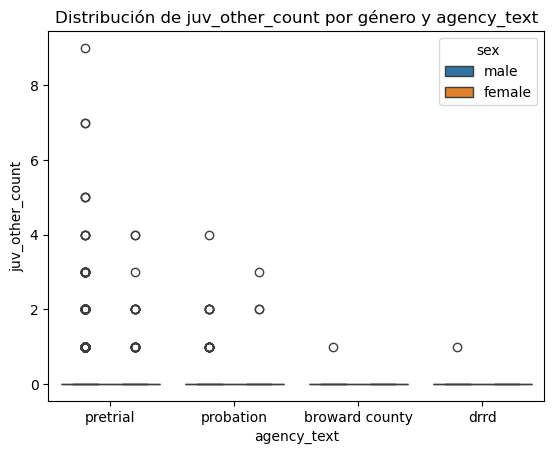

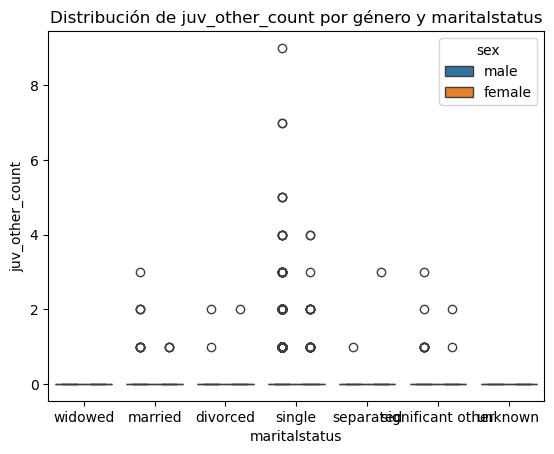

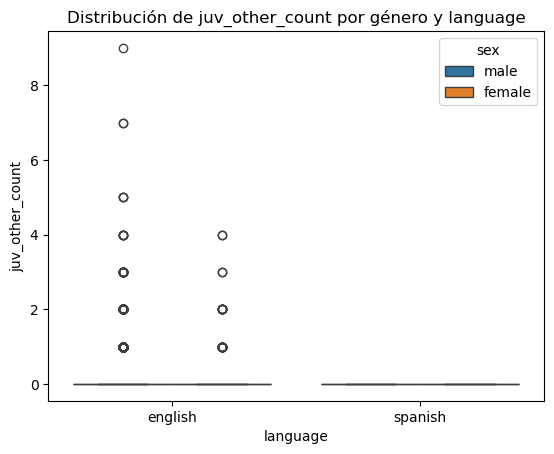

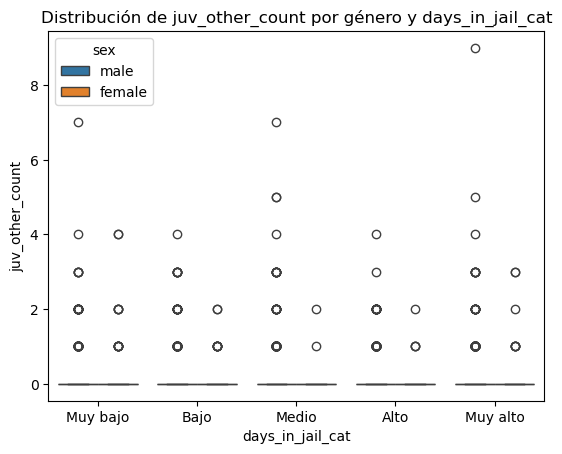

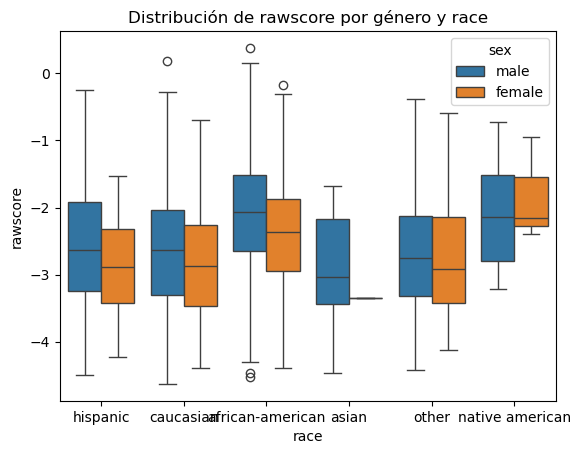

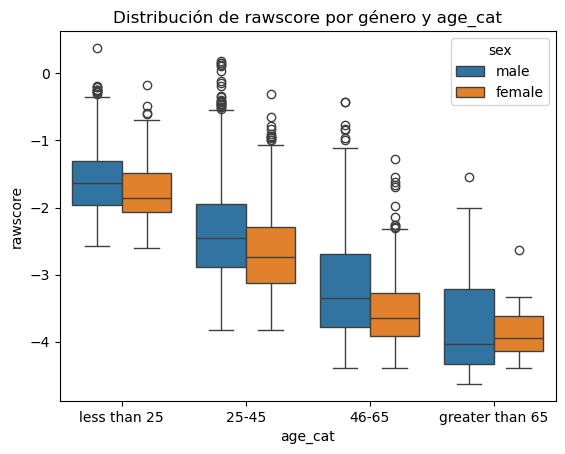

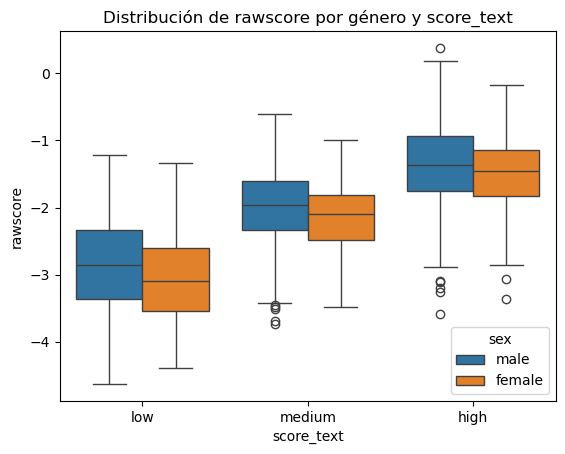

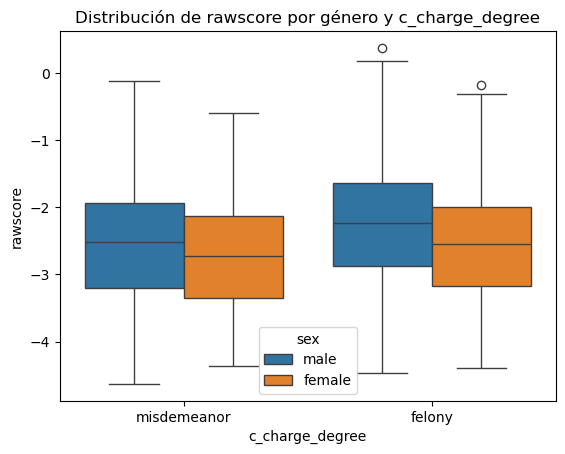

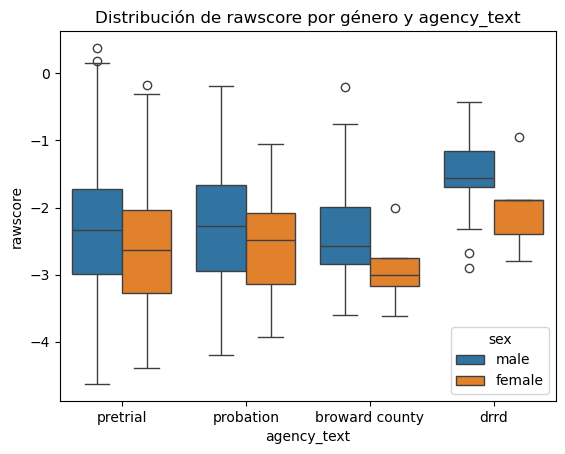

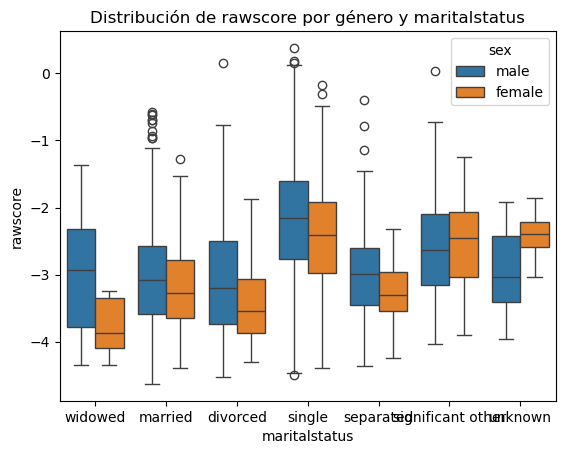

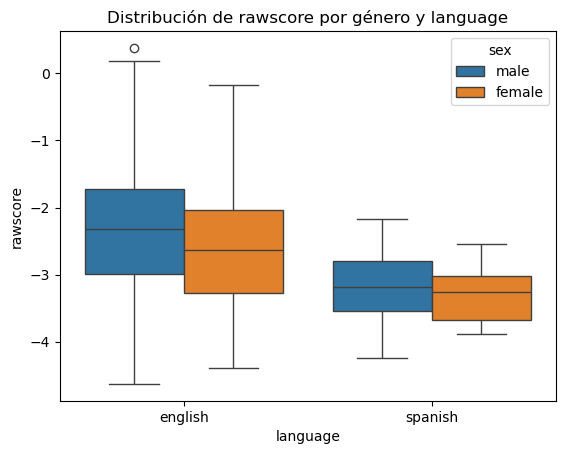

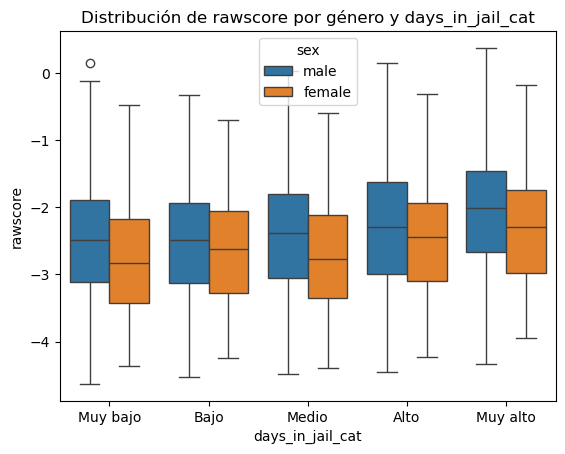

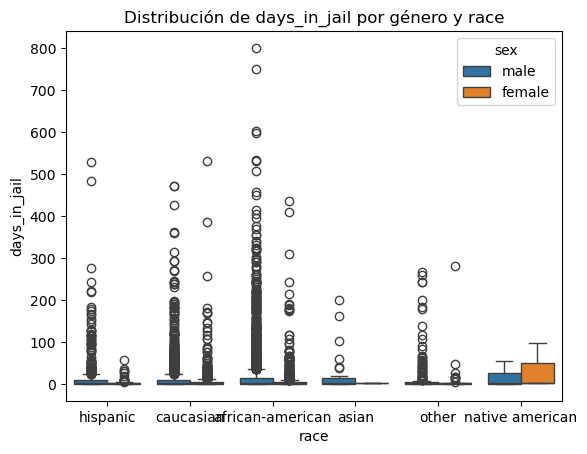

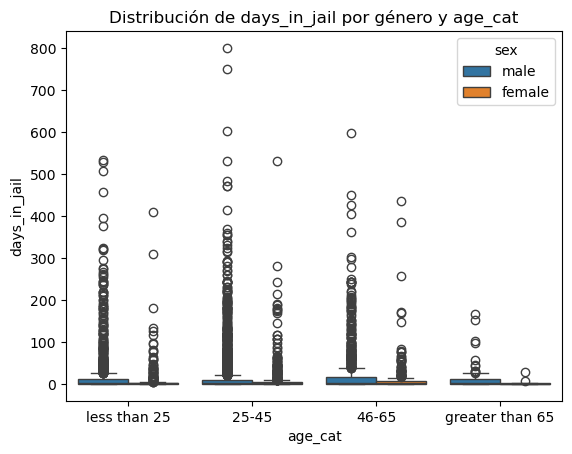

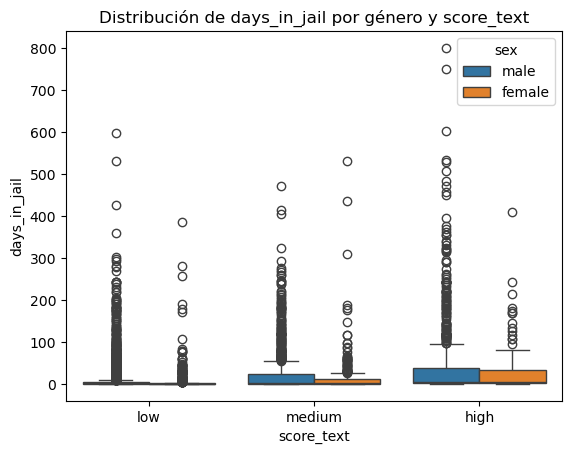

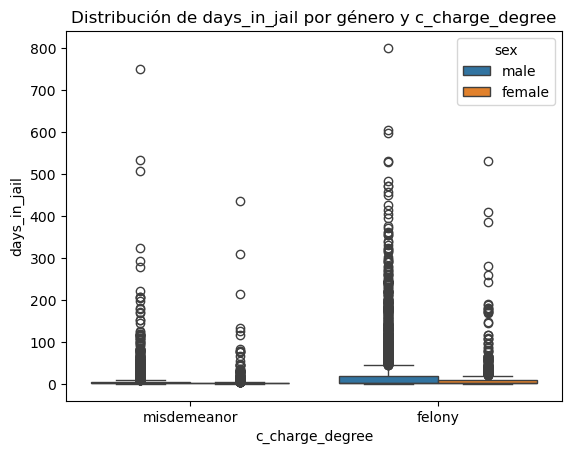

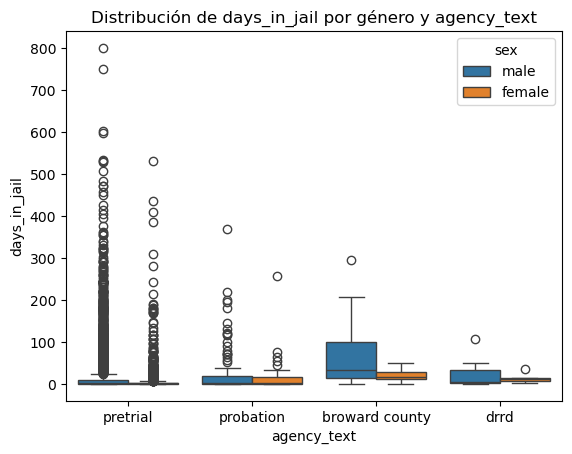

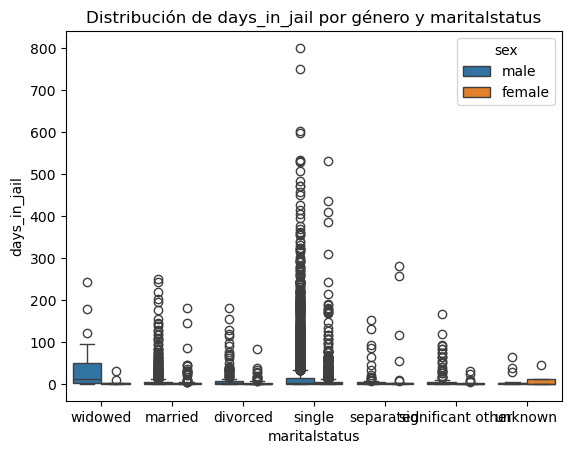

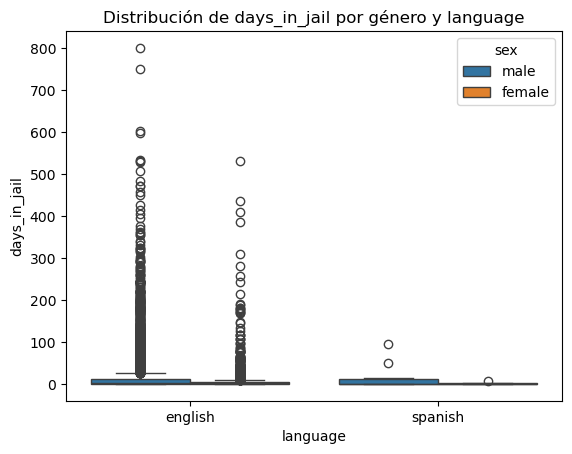

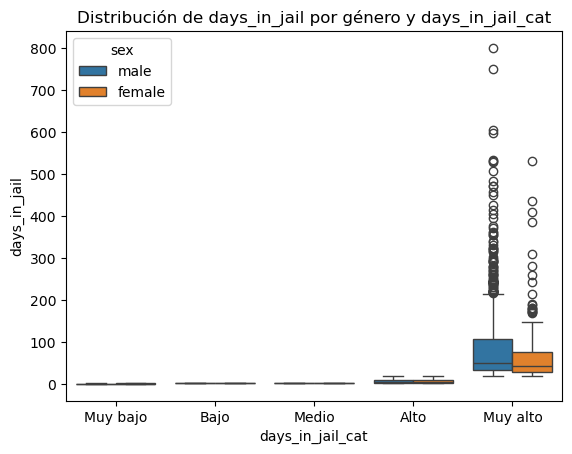

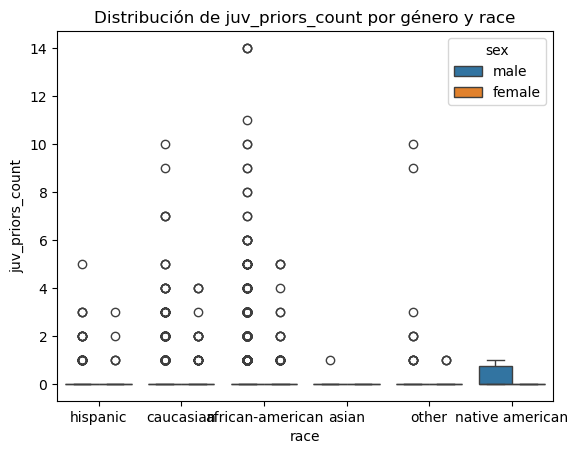

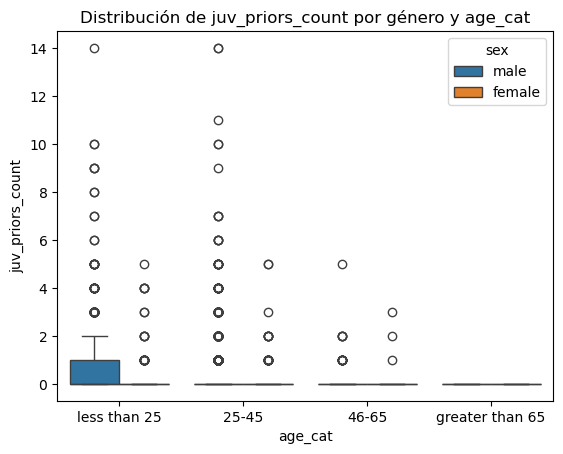

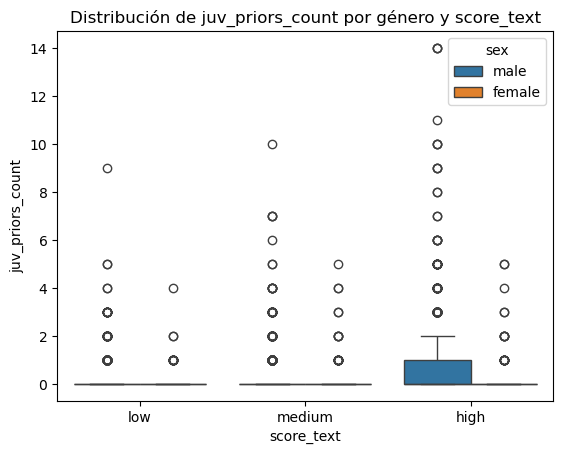

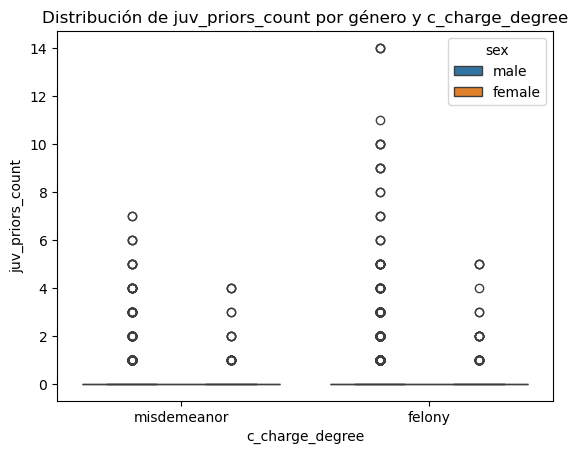

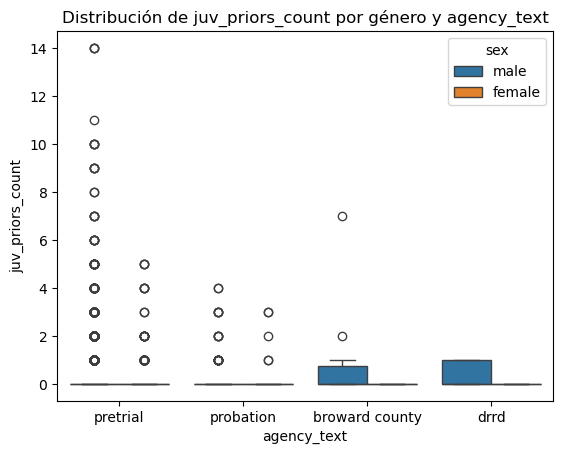

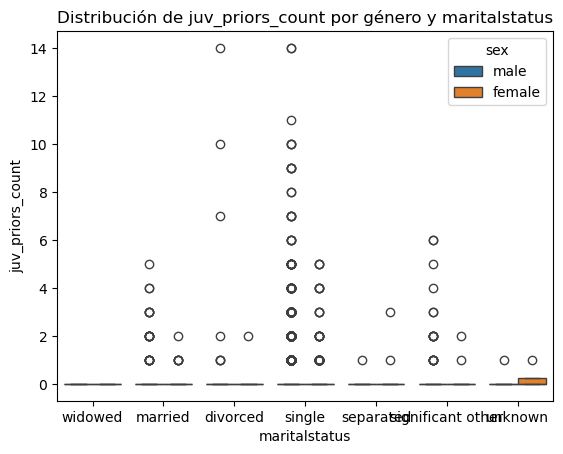

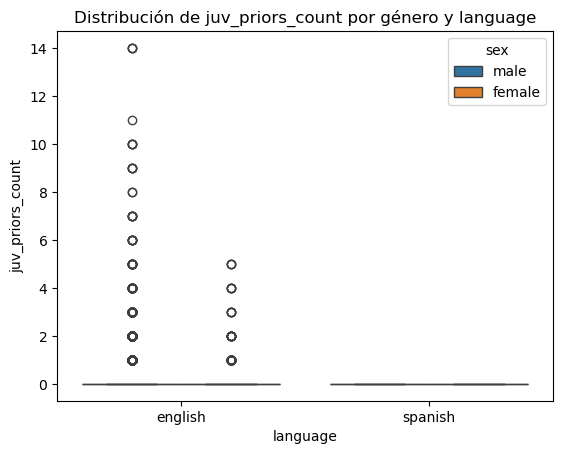

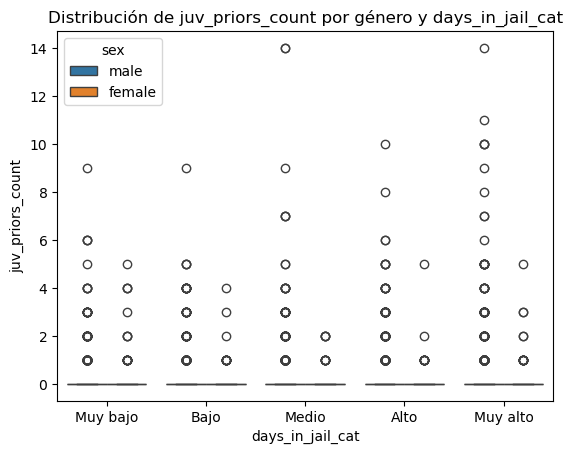

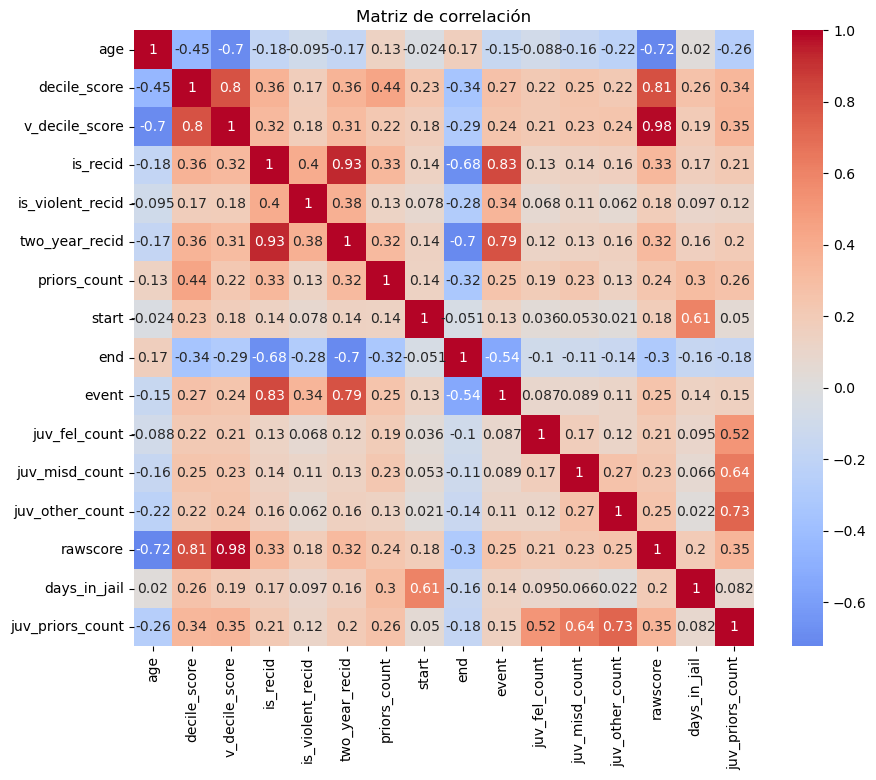


Crosstab entre sex y race


race,african-american,asian,caucasian,hispanic,native american,other,All
sex,,,,,,,
female,529,1,458,85,3,55,1131
male,2415,27,1573,427,10,267,4719
All,2944,28,2031,512,13,322,5850



Crosstab entre sex y score_text


score_text,low,medium,high,All
sex,,,,
female,690,320,121,1131
male,2637,1182,900,4719
All,3327,1502,1021,5850



Crosstab entre sex y c_charge_degree


...

is_recid,0,1,All
days_in_jail_cat,,,
Muy bajo,788,382,1170
Bajo,781,389,1170
Medio,732,438,1170
Alto,625,545,1170
Muy alto,533,637,1170
All,3459,2391,5850



Crosstab entre days_in_jail_cat y is_violent_recid


is_violent_recid,0,1,All
days_in_jail_cat,,,
Muy bajo,1086,84,1170
Bajo,1086,84,1170
Medio,1070,100,1170
Alto,1031,139,1170
Muy alto,1000,170,1170
All,5273,577,5850



Crosstab entre is_recid y is_violent_recid


is_violent_recid,0,1,All
is_recid,,,
0,3459,0,3459
1,1814,577,2391
All,5273,577,5850


In [11]:
eda(df)

In [12]:
# grupos = [
#     grupo["priors_count"].values
#     for nombre, grupo in df.groupby("race")
# ]


# F, p = f_oneway(*grupos)

# print("F:", F)
# print("p-value:", p)

In [13]:
# df_count = (
#         df['ethnic_code_text']
#         .value_counts()
#         .reset_index()
#     )

In [ ]:
df['prediccion'] = (df['decile_score'] >= 5).astype(int)

In [36]:
def check_bias(df):
    lista_demograficas = ['race','age_cat', 'sex', 'maritalstatus']
    for variable in lista_demograficas:
        print(f"\nVariable: {variable}")
        for grupo in df[variable].unique():
            subset = df[df[variable] == grupo]
            
            cm = confusion_matrix(subset['is_recid'], subset['prediccion'])
            cm_df = pd.DataFrame(cm, index=['Yes', 'No'], columns=['Yes', 'No'])

            cm_all = confusion_matrix(subset['is_recid'], subset['prediccion'], normalize='all')
            cm_all_df = pd.DataFrame(cm_all, index=['Yes', 'No'], columns=['Yes', 'No'])

            cm_true = confusion_matrix(subset['is_recid'], subset['prediccion'], normalize = 'true')
            cm_true_df = pd.DataFrame(cm_true, index=['Yes', 'No'], columns=['Yes', 'No'])

            print(f"\nGrupo: {grupo}")
            display(cm_df)
            print("\nNormalize All")
            display(cm_all_df)
            print("\nNormalize True")
            display(cm_true_df)

In [37]:
check_bias(df)


Variable: race

Grupo: hispanic


,Yes,No
Yes,281,70
No,85,76



Normalize All


,Yes,No
Yes,0.548828,0.136719
No,0.166016,0.148438



Normalize True


...

,Yes,No
Yes,11,5
No,6,1



Normalize All


,Yes,No
Yes,0.478261,0.217391
No,0.260870,0.043478



Normalize True


,Yes,No
Yes,0.687500,0.312500
No,0.857143,0.142857


In [ ]:


for grupo in df['race'].unique():
    subset = df[df['race'] == grupo]
    
    cm = confusion_matrix(subset['is_recid'], subset['prediccion'])
    
    print(f"\nGrupo: {grupo}")
    print(cm)


Grupo: hispanic
[[281  70]
 [ 85  76]]

Grupo: caucasian
[[1041  305]
 [ 346  339]]

Grupo: african-american
[[ 872  644]
 [ 415 1013]]

Grupo: asian
[[20  1]
 [ 2  5]]

Grupo: other
[[191  28]
 [ 70  33]]

Grupo: native american
[[4 2]
 [0 7]]


In [16]:
for grupo in df['race'].unique():
    subset = df[df['race'] == grupo]
    
    cm = confusion_matrix(subset['is_recid'], subset['prediccion'], normalize='all')
    
    print(f"\nGrupo: {grupo}")
    print(cm)


Grupo: hispanic
[[0.54882812 0.13671875]
 [0.16601562 0.1484375 ]]

Grupo: caucasian
[[0.51255539 0.15017233]
 [0.17035943 0.16691285]]

Grupo: african-american
[[0.29619565 0.21875   ]
 [0.14096467 0.34408967]]

Grupo: asian
[[0.71428571 0.03571429]
 [0.07142857 0.17857143]]

Grupo: other
[[0.5931677  0.08695652]
 [0.2173913  0.10248447]]

Grupo: native american
[[0.30769231 0.15384615]
 [0.         0.53846154]]


In [17]:
for grupo in df['race'].unique():
    subset = df[df['race'] == grupo]
    
    cm = confusion_matrix(subset['is_recid'], subset['prediccion'], normalize = 'true')
    
    print(f"\nGrupo: {grupo}")
    print(cm)


Grupo: hispanic
[[0.8005698  0.1994302 ]
 [0.52795031 0.47204969]]

Grupo: caucasian
[[0.77340267 0.22659733]
 [0.50510949 0.49489051]]

Grupo: african-american
[[0.57519789 0.42480211]
 [0.29061625 0.70938375]]

Grupo: asian
[[0.95238095 0.04761905]
 [0.28571429 0.71428571]]

Grupo: other
[[0.87214612 0.12785388]
 [0.67961165 0.32038835]]

Grupo: native american
[[0.66666667 0.33333333]
 [0.         1.        ]]
